In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
file_kec = "Kecelakaan kerja 3 tahun.xlsx"
df_kec_raw = pd.read_excel('Kecelakaan kerja 3 tahun.xlsx', sheet_name="Sheet1", header=3)

print("Kolom yang tersedia:", df_kec_raw.columns.tolist())

# Rename 'Unnamed: 1' to 'Provinsi' to make it accessible
df_kec_raw = df_kec_raw.rename(columns={'Unnamed: 1': 'Provinsi'})

# Hapus baris yang kosong
df_kec_raw = df_kec_raw.dropna(subset=["Provinsi"], how="all")
df_kec = df_kec_raw[df_kec_raw["Provinsi"].notna() & (df_kec_raw["Provinsi"] != "Jumlah")].copy()

#Mapping kolom
# Ensure these indices refer to df_kec_raw (which has all original columns + 'Provinsi')
kolom_2023 = df_kec_raw.columns[14]  # 'Konstruksi'
kolom_2024 = df_kec_raw.columns[4]   # 'Jasa Konstruksi'
kolom_2025 = df_kec_raw.columns[9]   # 'Jasa Konstruksi.1'

df_kec["kecelakaan_konstruksi_2023"] = df_kec[kolom_2023]
df_kec["kecelakaan_konstruksi_2024"] = df_kec[kolom_2024]
df_kec["kecelakaan_konstruksi_2025"] = df_kec[kolom_2025]

# Pilih kolom yang diperlukan
df_kec = df_kec[["Provinsi",
                 "kecelakaan_konstruksi_2023",
                 "kecelakaan_konstruksi_2024",
                 "kecelakaan_konstruksi_2025"]]

Kolom yang tersedia: ['Unnamed: 0', 'Unnamed: 1', 'PU', 'BPU', 'Jasa Konstruksi', 'Unnamed: 5', 'Unnamed: 6', 'PU.1', 'BPU.1', 'Jasa Konstruksi.1', 'Unnamed: 10', 'Unnamed: 11', 'PU.2', 'BPU.2', 'Konstruksi', 'Jumlah', 'Unnamed: 16']


In [ ]:
file_perusahaan = "Perusahaan Konstruksi Jawa 2025.xlsx"
sheets = ["Jatim", "Jateng", "Jawa Barat", "Banten"]
provinsi_map = {
    "Jatim": "Jawa Timur",
    "Jateng": "Jawa Tengah",
    "Jawa Barat": "Jawa Barat",
    "Banten": "Banten"
}

list_perusahaan = []
list_hotspot = []

for sheet in sheets:
    df_temp = pd.read_excel(file_perusahaan, sheet_name=sheet, header=1)
    # Convert all column names to string type to prevent TypeError with 'in' operator
    df_temp.columns = df_temp.columns.astype(str)
    last_row = df_temp.iloc[-1]

    if "Jumlah 2" in df_temp.columns:
        total_perusahaan = last_row["Jumlah 2"]
    elif "Jumlah" in df_temp.columns:
        total_perusahaan = last_row["Jumlah"]
    else:
        numeric_values = pd.to_numeric(last_row.iloc[2:], errors='coerce').dropna()
        if not numeric_values.empty:
            total_perusahaan = numeric_values.max()
        else:
            raise ValueError(f"Could not find a suitable 'Total' value for total_perusahaan in sheet '{sheet}'.")

    pt = last_row["PT/Persero"] if "PT/Persero" in df_temp.columns else 0
    cv = last_row["CV"] if "CV" in df_temp.columns else 0
    koperasi = last_row["Koperasi"] if "Koperasi" in df_temp.columns else 0
    if "Lainnya" in df_temp.columns:
        lainnya = last_row["Lainnya"]
    elif "Kantor Perwakilan BUJKA" in df_temp.columns:
        lainnya = last_row["Kantor Perwakilan BUJKA"] + (last_row.get("Lainnya", 0))
    else:
        lainnya = 0

    list_perusahaan.append({
        "Provinsi": provinsi_map[sheet],
        "total_perusahaan": total_perusahaan,
        "PT": pt,
        "CV": cv,
        "Koperasi": koperasi,
        "Lainnya": lainnya
    })

    # Hotspot per kab/kota
    kab_col = "Kabupaten/Kota"
    # If 'Kabupaten/Kota' column name is not explicitly found, assume it's the second column.
    if kab_col not in df_temp.columns:
        kab_col = df_temp.columns[1]

    # Identify the column containing the total number of companies for each city/regency.
    if "Jumlah 2" in df_temp.columns:
        jumlah_col = "Jumlah 2"
    elif "Jumlah" in df_temp.columns:
        jumlah_col = "Jumlah"
    else:
        # Fallback for sheets like 'Banten' where total is in a numeric-named column, often the last one.
        jumlah_col = df_temp.columns[-1]

    df_hot = df_temp[df_temp[kab_col].notna()].copy()
    df_hot = df_hot[~df_hot[kab_col].isin(["Jumlah", "Total", "Jumlah ", "Total "])]
    for _, row in df_hot.iterrows():
        list_hotspot.append({
            "Provinsi": provinsi_map[sheet],
            "Kabupaten_Kota": str(row[kab_col]).strip(),
            "Jumlah_Perusahaan": row[jumlah_col] if pd.notna(row[jumlah_col]) else 0
        })


In [ ]:
df_perusahaan = pd.DataFrame(list_perusahaan)
df_hotspot = pd.DataFrame(list_hotspot)
df_hotspot = df_hotspot.sort_values("Jumlah_Perusahaan", ascending=False)


In [ ]:
#count data and metric
df_merged = df_kec.merge(df_perusahaan, on="Provinsi", how="left")

# Opportunity Score = Kecelakaan konstruksi 2025 + Total Perusahaan
df_merged["opportunity_score"] = df_merged["kecelakaan_konstruksi_2025"] + df_merged["total_perusahaan"]

# Trends in changing construction accidents
df_merged["tren_2024_2025"] = ((df_merged["kecelakaan_konstruksi_2025"] - df_merged["kecelakaan_konstruksi_2024"])
                                 / df_merged["kecelakaan_konstruksi_2024"] * 100)
df_merged["tren_2023_2025"] = ((df_merged["kecelakaan_konstruksi_2025"] - df_merged["kecelakaan_konstruksi_2023"])
                                 / df_merged["kecelakaan_konstruksi_2023"] * 100)

# Ratio construction accident per 1000
df_merged["risk_density"] = (df_merged["kecelakaan_konstruksi_2025"] / df_merged["total_perusahaan"]) * 1000

# market share
df_merged["pangsa_pasar"] = df_merged["total_perusahaan"] / df_merged["total_perusahaan"].sum() * 100

# B2B priority
df_merged["prioritas_b2b"] = pd.cut(df_merged["opportunity_score"],
                                    bins=4,
                                    labels=["Rendah", "Sedang", "Tinggi", "Prioritas Utama"],
                                    include_lowest=True)


In [ ]:
#Analysis results

print("\n" + "="*80)
print("DATA KECELAKAAN SEKTOR KONSTRUKSI PER PROVINSI")
print("="*80)
print(df_merged[["Provinsi", "kecelakaan_konstruksi_2023", "kecelakaan_konstruksi_2024", "kecelakaan_konstruksi_2025"]]
      .to_string(index=False))

print("\n" + "="*80)
print("CONSTRUCTION BUSINESS OPPORTUNITY ANALYSIS (Ukuran Pasar)")
print("="*80)
print(df_merged[["Provinsi", "total_perusahaan", "pangsa_pasar"]].sort_values("total_perusahaan", ascending=False))

print("\n" + "="*80)
print("CONSTRUCTION RISK OPPORTUNITY ANALYSIS (Opportunity Score)")
print("Formula: Kecelakaan Konstruksi 2025 + Jumlah Perusahaan")
print("="*80)
print(df_merged[["Provinsi", "kecelakaan_konstruksi_2025", "total_perusahaan", "opportunity_score"]]
      .sort_values("opportunity_score", ascending=False))

print("\n" + "="*80)
print("B2B MARKET PRIORITIZATION")
print("="*80)
print(df_merged[["Provinsi", "opportunity_score", "tren_2024_2025", "prioritas_b2b"]]
      .sort_values("opportunity_score", ascending=False))

print("\n" + "="*80)
print("REGIONAL CONSTRUCTION HOTSPOT (Top 15 Kab/Kota)")
print("="*80)
print(df_hotspot[["Provinsi", "Kabupaten_Kota", "Jumlah_Perusahaan"]].head(15).to_string(index=False))

print("\n" + "="*80)
print("RISK DENSITY (Kecelakaan Konstruksi per 1000 Perusahaan)")
print("="*80)
print(df_merged[["Provinsi", "risk_density"]].sort_values("risk_density", ascending=False))



DATA KECELAKAAN SEKTOR KONSTRUKSI PER PROVINSI
            Provinsi  kecelakaan_konstruksi_2023  kecelakaan_konstruksi_2024  kecelakaan_konstruksi_2025
                Aceh                           6                          11                          24
      Sumatera Utara                         156                         247                         158
      Sumatera Barat                          82                         105                          60
                Riau                         180                         180                         151
               Jambi                          16                          15                           5
    Sumatera Selatan                           7                          27                          35
            Bengkulu                           5                           7                          13
             Lampung                           5                           8                          20
Kep. Ba

/tmp/ipykernel_918/55078564.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_merged.sort_values("kecelakaan_konstruksi_2025", ascending=False),


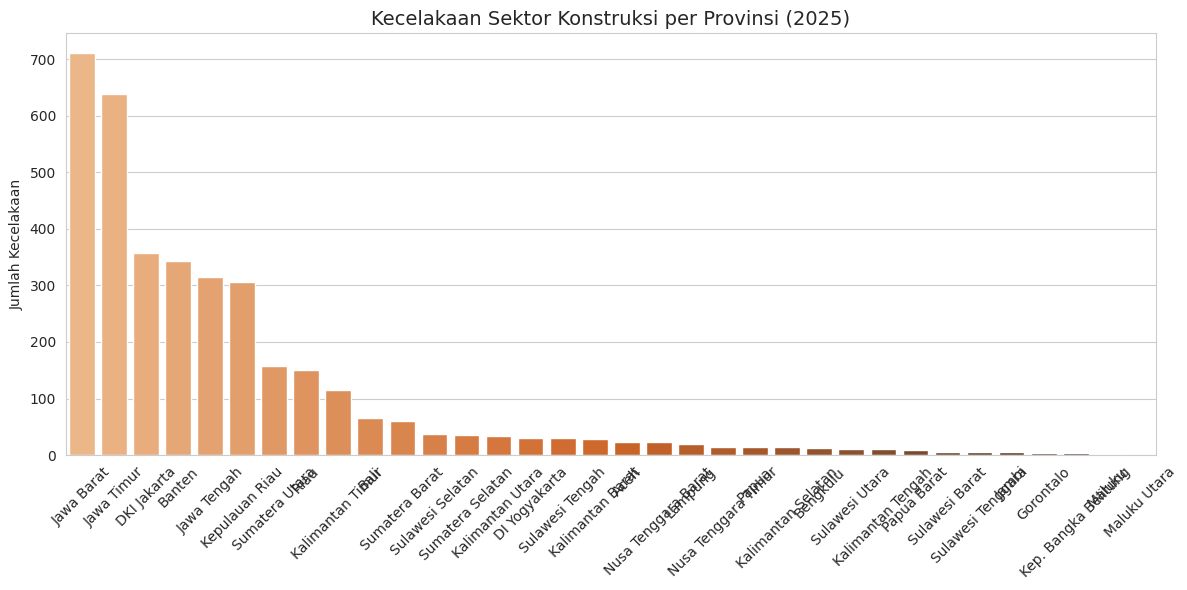

/tmp/ipykernel_918/55078564.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_merged.sort_values("opportunity_score", ascending=False),


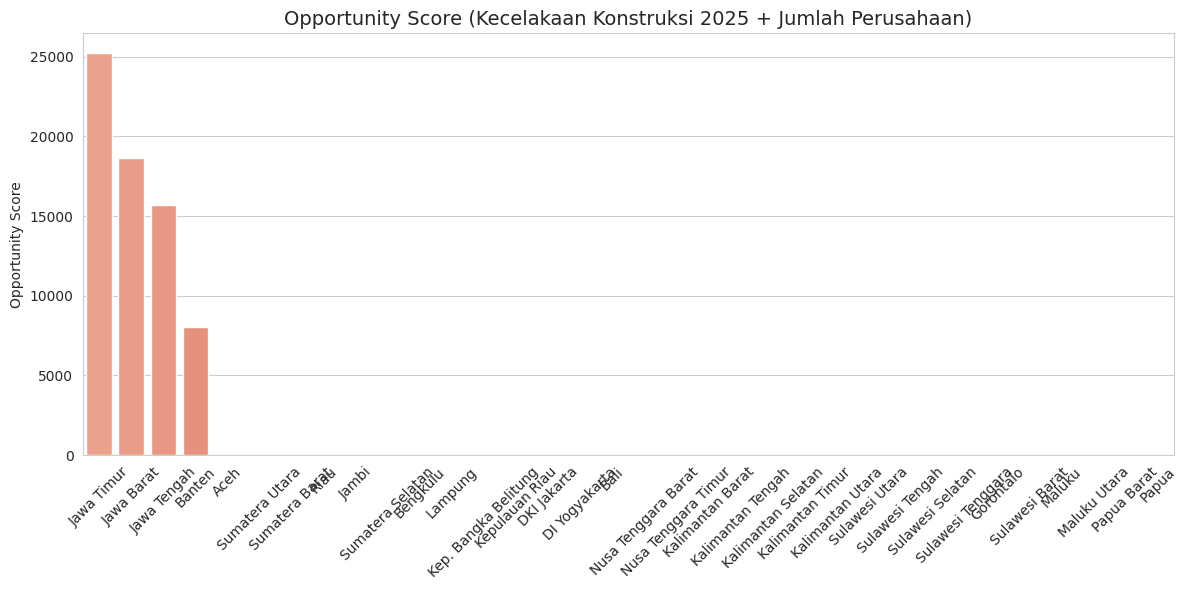

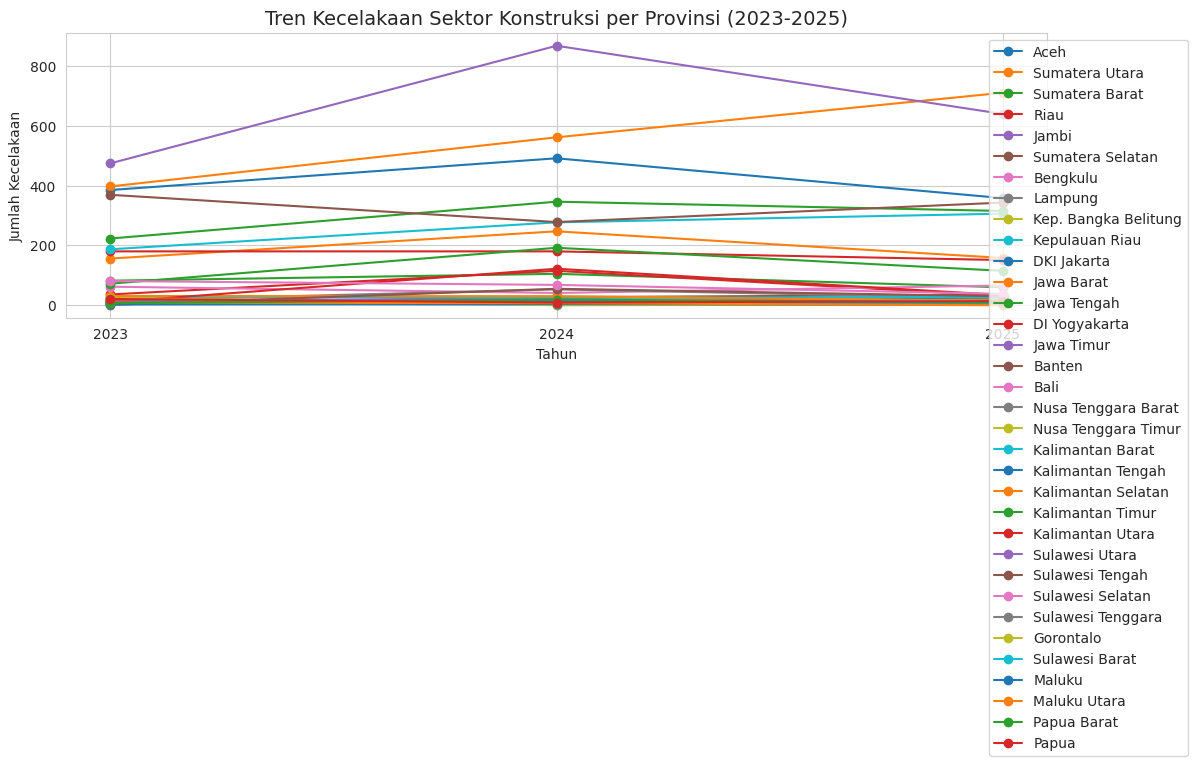

/tmp/ipykernel_918/55078564.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_merged.sort_values("risk_density", ascending=False),


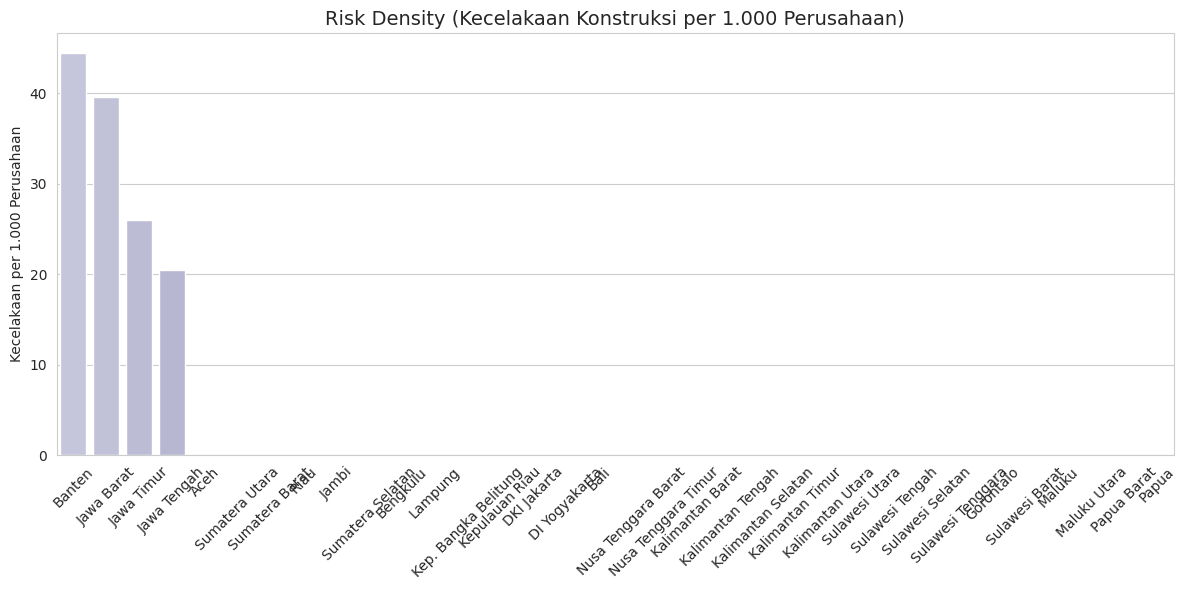

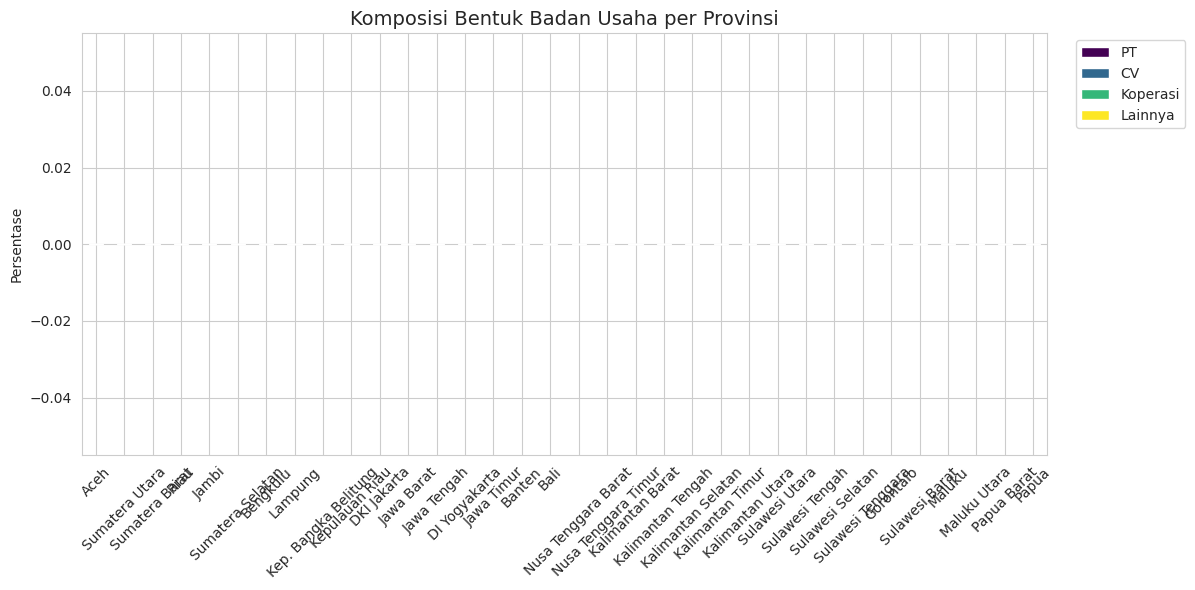

/tmp/ipykernel_918/55078564.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hotspot, y="Kabupaten_Kota", x="Jumlah_Perusahaan",


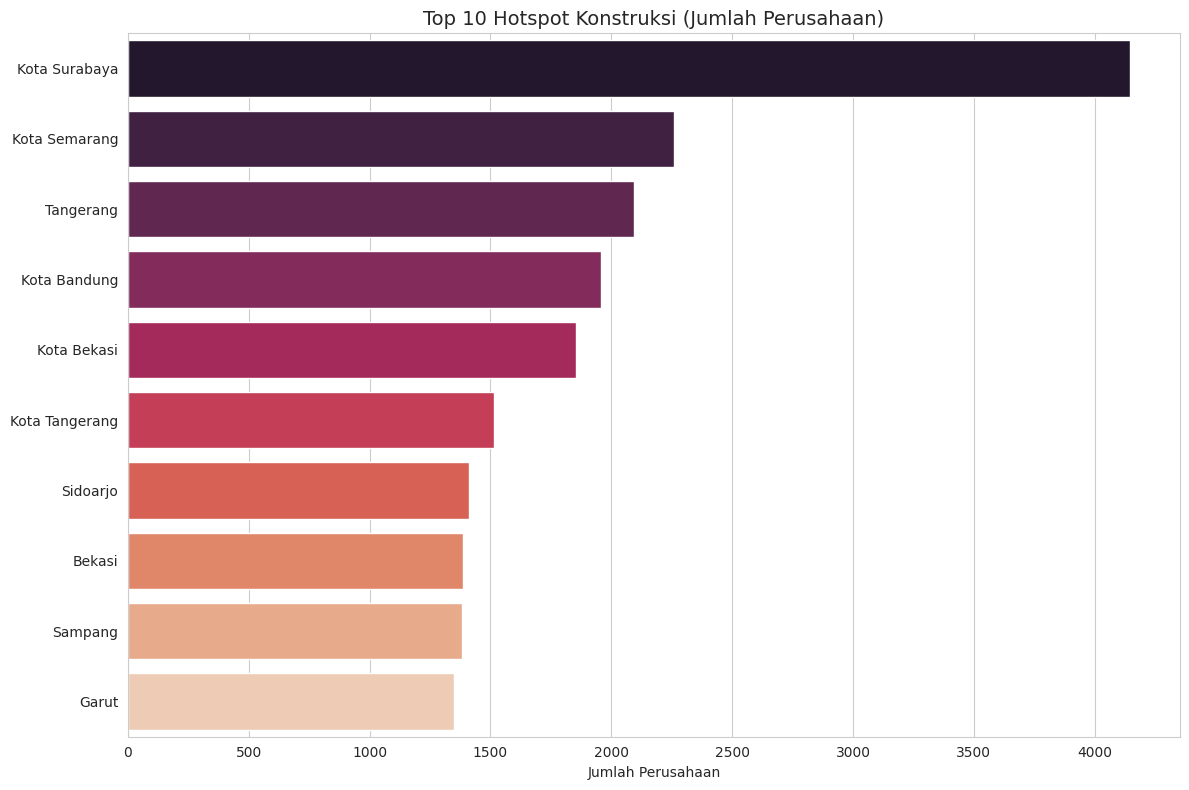

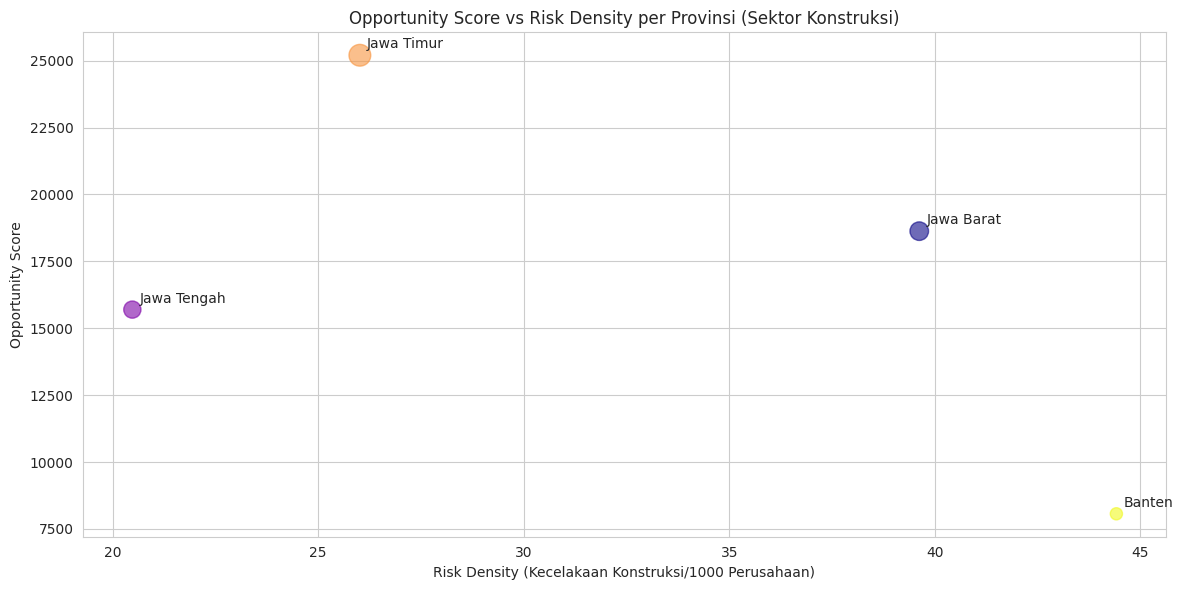

In [ ]:
#visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# construction accident sum per provinsi (2025)
fig1, ax1 = plt.subplots()
sns.barplot(data=df_merged.sort_values("kecelakaan_konstruksi_2025", ascending=False),
            x="Provinsi", y="kecelakaan_konstruksi_2025", palette="Oranges_d")
ax1.set_title("Kecelakaan Sektor Konstruksi per Provinsi (2025)", fontsize=14)
ax1.set_ylabel("Jumlah Kecelakaan")
ax1.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("1_kecelakaan_konstruksi_2025.png")
plt.show()

# Opportunity Score
fig2, ax2 = plt.subplots()
sns.barplot(data=df_merged.sort_values("opportunity_score", ascending=False),
            x="Provinsi", y="opportunity_score", palette="Reds_d")
ax2.set_title("Opportunity Score (Kecelakaan Konstruksi 2025 + Jumlah Perusahaan)", fontsize=14)
ax2.set_ylabel("Opportunity Score")
ax2.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("2_opportunity_score.png")
plt.show()

# construction accident tren 2023-2025
df_trend = df_merged.melt(id_vars=["Provinsi"],
                          value_vars=["kecelakaan_konstruksi_2023", "kecelakaan_konstruksi_2024", "kecelakaan_konstruksi_2025"],
                          var_name="Tahun", value_name="Jumlah Kecelakaan")
df_trend["Tahun"] = df_trend["Tahun"].str.replace("kecelakaan_konstruksi_", "")
fig3, ax3 = plt.subplots()
for prov in df_merged["Provinsi"]:
    data = df_trend[df_trend["Provinsi"] == prov]
    ax3.plot(data["Tahun"], data["Jumlah Kecelakaan"], marker='o', label=prov)
ax3.set_title("Tren Kecelakaan Sektor Konstruksi per Provinsi (2023-2025)", fontsize=14)
ax3.set_xlabel("Tahun")
ax3.set_ylabel("Jumlah Kecelakaan")
ax3.legend(loc="upper right", bbox_to_anchor=(1.15,1))
plt.tight_layout()
plt.savefig("3_tren_kecelakaan_konstruksi.png")
plt.show()

# Risk Density (kecelakaan konstruksi per 1000 perusahaan)
fig4, ax4 = plt.subplots()
sns.barplot(data=df_merged.sort_values("risk_density", ascending=False),
            x="Provinsi", y="risk_density", palette="Purples_d")
ax4.set_title("Risk Density (Kecelakaan Konstruksi per 1.000 Perusahaan)", fontsize=14)
ax4.set_ylabel("Kecelakaan per 1.000 Perusahaan")
ax4.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("4_risk_density.png")
plt.show()

# Segmentasi Badan Usaha (Stacked Bar)
fig5, ax5 = plt.subplots()
df_bentuk = df_merged.set_index("Provinsi")[["PT", "CV", "Koperasi", "Lainnya"]]
df_bentuk_persen = df_bentuk.div(df_bentuk.sum(axis=1), axis=0) * 100
df_bentuk_persen.plot(kind="bar", stacked=True, ax=ax5, colormap="viridis")
ax5.set_title("Komposisi Bentuk Badan Usaha per Provinsi", fontsize=14)
ax5.set_ylabel("Persentase")
ax5.set_xlabel("")
plt.xticks(rotation=45)
plt.legend(loc="upper right", bbox_to_anchor=(1.15,1))
plt.tight_layout()
plt.savefig("5_segmentasi_usaha.png")
plt.show()

# Top 10 Hotspot
top_hotspot = df_hotspot.head(10)
fig6, ax6 = plt.subplots(figsize=(12,8))
sns.barplot(data=top_hotspot, y="Kabupaten_Kota", x="Jumlah_Perusahaan",
            palette="rocket", orient='h')
ax6.set_title("Top 10 Hotspot Konstruksi (Jumlah Perusahaan)", fontsize=14)
ax6.set_xlabel("Jumlah Perusahaan")
ax6.set_ylabel("")
plt.tight_layout()
plt.savefig("6_hotspot.png")
plt.show()

# Scatter: Opportunity Score vs Risk Density
fig7, ax7 = plt.subplots()
scatter = ax7.scatter(df_merged["risk_density"], df_merged["opportunity_score"],
                      s=df_merged["total_perusahaan"]/100, alpha=0.6, c=range(len(df_merged)), cmap="plasma")
for _, row in df_merged.iterrows():
    ax7.annotate(row["Provinsi"], (row["risk_density"], row["opportunity_score"]),
                 xytext=(5,5), textcoords="offset points")
ax7.set_xlabel("Risk Density (Kecelakaan Konstruksi/1000 Perusahaan)")
ax7.set_ylabel("Opportunity Score")
ax7.set_title("Opportunity Score vs Risk Density per Provinsi (Sektor Konstruksi)")
plt.tight_layout()
plt.savefig("7_score_vs_risk.png")
plt.show()


In [ ]:
# excel result
with pd.ExcelWriter("Hasil_Analisis_Konstruksi_Sektor_Konstruksi.xlsx") as writer:
    df_merged.to_excel(writer, sheet_name="Ringkasan Provinsi", index=False)
    df_hotspot.to_excel(writer, sheet_name="Hotspot Kab_Kota", index=False)
    df_bentuk.to_excel(writer, sheet_name="Segmentasi Badan Usaha")
print("\nHasil analisis (khusus sektor konstruksi) disimpan ke 'Hasil_Analisis_Konstruksi_Sektor_Konstruksi.xlsx'")


Hasil analisis (khusus sektor konstruksi) disimpan ke 'Hasil_Analisis_Konstruksi_Sektor_Konstruksi.xlsx'


In [ ]:
#conclusion
print("\n" + "="*80)
print("KESIMPULAN & REKOMENDASI (BERDASARKAN DATA KONSTRUKSI)")
print("="*80)
print(f"- Opportunity Score tertinggi: {df_merged.loc[df_merged['opportunity_score'].idxmax(), 'Provinsi']}")
print(f"- Risk density tertinggi: {df_merged.loc[df_merged['risk_density'].idxmax(), 'Provinsi']}")
print("- Fokus prioritas B2B pada provinsi dengan label 'Prioritas Utama'.")
print("- Hotspot utama: Surabaya, Semarang, Tangerang, Bandung, Bekasi.")
print("- Segmentasi: CV dominan (70-85%) -> strategi produk untuk UKM.")


KESIMPULAN & REKOMENDASI (BERDASARKAN DATA KONSTRUKSI)
- Opportunity Score tertinggi: Jawa Timur
- Risk density tertinggi: Banten
- Fokus prioritas B2B pada provinsi dengan label 'Prioritas Utama'.
- Hotspot utama: Surabaya, Semarang, Tangerang, Bandung, Bekasi.
- Segmentasi: CV dominan (70-85%) -> strategi produk untuk UKM.


**One by One**

**Construction Company Density Analysis**

CONSTRUCTION COMPANY DENSITY ANALYSIS
Wilayah dengan Jumlah Perusahaan Konstruksi Terbesar

--- RANKING PROVINSI ---
   Provinsi  Jumlah_Perusahaan
 Jawa Timur              24564
 Jawa Barat              17919
Jawa Tengah              15382
     Banten               7722

--- TOP 15 KABUPATEN/KOTA DENGAN PERUSAHAAN TERBANYAK ---
   Provinsi         Kabupaten_Kota  Jumlah_Perusahaan
 Jawa Timur          Kota Surabaya               4146
Jawa Tengah          Kota Semarang               2259
     Banten              Tangerang               2093
 Jawa Barat           Kota Bandung               1956
 Jawa Barat            Kota Bekasi               1854
     Banten         Kota Tangerang               1516
 Jawa Timur               Sidoarjo               1412
 Jawa Barat                 Bekasi               1387
 Jawa Timur                Sampang               1383
 Jawa Barat                  Garut               1350
     Banten Kota Tangerang Selatan               1337
 Jawa Barat          

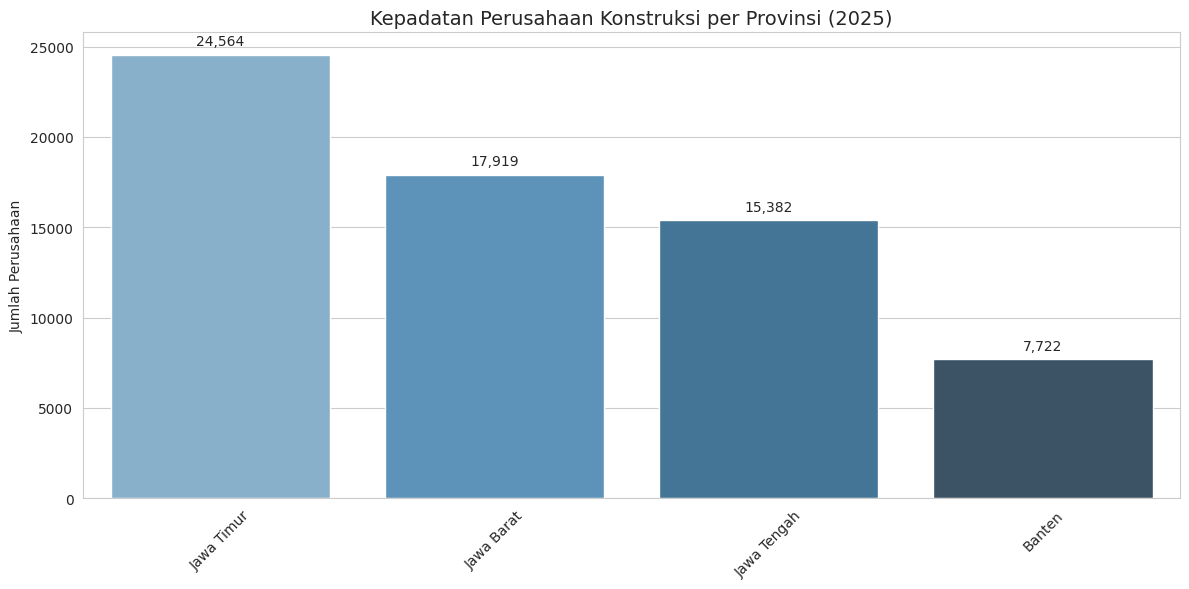

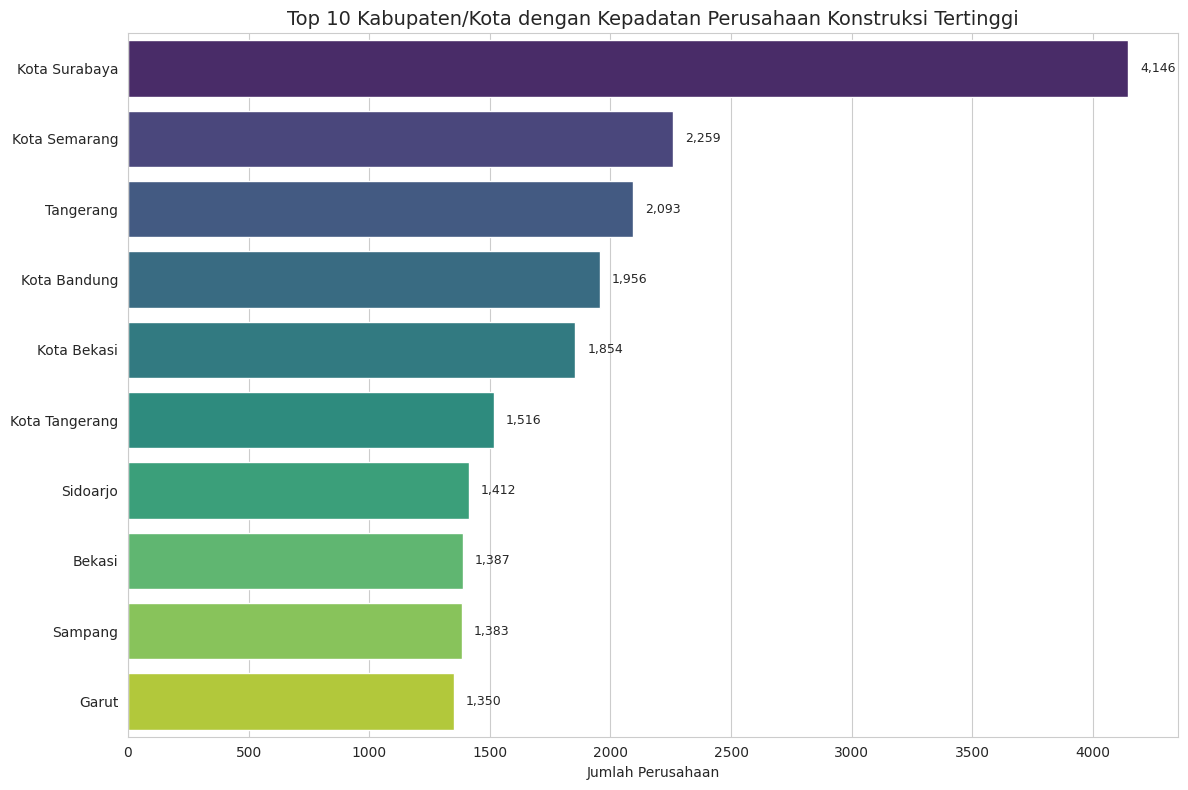

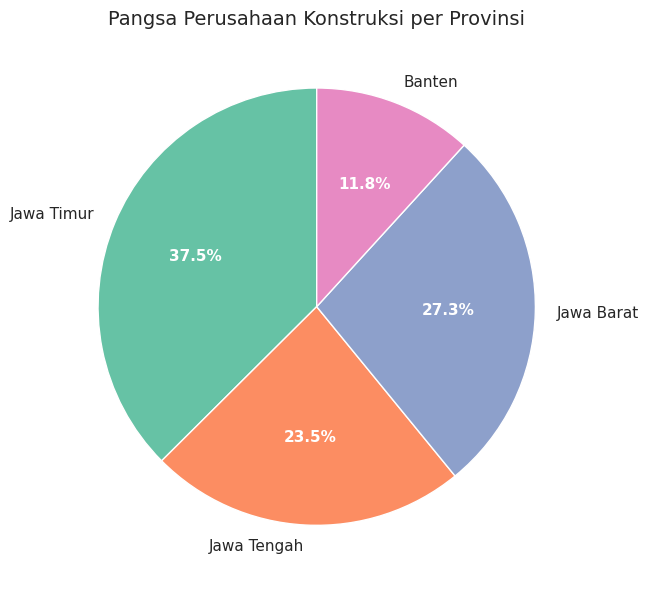

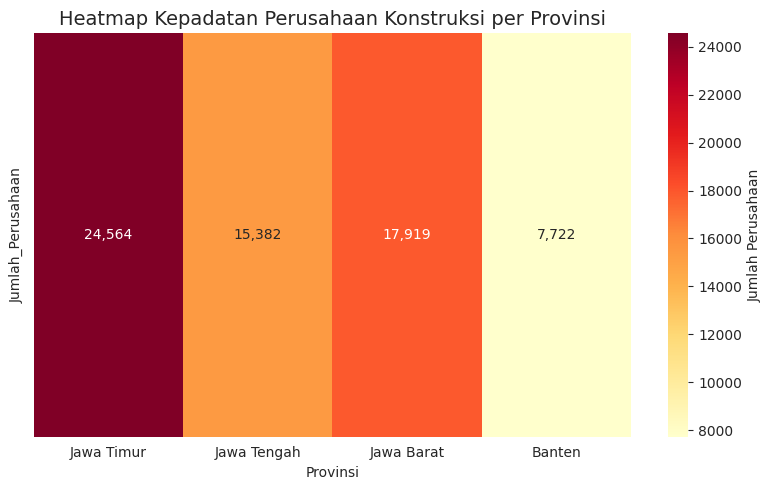


Grafik telah disimpan:
 - company_density_province.png
 - company_density_top10_cities.png
 - company_density_pie.png
 - company_density_heatmap.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# BACA DATA PERUSAHAAN KONSTRUKSI DARI SEMUA SHEET
# =============================================================================
file_perusahaan = "Perusahaan Konstruksi Jawa 2025.xlsx"
sheets = ["Jatim", "Jateng", "Jawa Barat", "Banten"]
provinsi_map = {
    "Jatim": "Jawa Timur",
    "Jateng": "Jawa Tengah",
    "Jawa Barat": "Jawa Barat",
    "Banten": "Banten"
}

list_provinsi = []
list_kabkota = []

for sheet in sheets:
    df = pd.read_excel(file_perusahaan, sheet_name=sheet, header=1)

    # Convert all column names to string type to prevent TypeError with 'in' operator
    df.columns = df.columns.astype(str)

    # Ambil total perusahaan provinsi dari baris terakhir
    last_row = df.iloc[-1]
    if "Jumlah 2" in df.columns:
        total_prov = last_row["Jumlah 2"]
    elif "Jumlah" in df.columns:
        total_prov = last_row["Jumlah"]
    else:
        # Fallback for sheets where 'Jumlah' is not in column names.
        # Assume the largest numeric value in the last row (excluding initial text columns)
        # represents the total number of companies.
        numeric_values = pd.to_numeric(last_row.iloc[2:], errors='coerce').dropna()
        if not numeric_values.empty:
            total_prov = numeric_values.max()
        else:
            raise ValueError(f"Could not find a suitable 'Total' value for total_prov in sheet '{sheet}'.")

    list_provinsi.append({
        "Provinsi": provinsi_map[sheet],
        "Jumlah_Perusahaan": total_prov
    })

    # Ambil data per kabupaten/kota
    kab_col = "Kabupaten/Kota"
    if kab_col not in df.columns:
        kab_col = df.columns[1]  # asumsi kolom kedua adalah nama kab/kota

    # Robustly identify the 'Jumlah' column for kab/kota data
    if "Jumlah 2" in df.columns:
        jumlah_col_kabkota = "Jumlah 2"
    elif "Jumlah" in df.columns:
        jumlah_col_kabkota = "Jumlah"
    else:
        # Fallback to the last column for kab/kota totals if explicit 'Jumlah' columns are not found
        jumlah_col_kabkota = df.columns[-1]

    # Filter baris yang bukan total
    df_kab = df[df[kab_col].notna()].copy()
    df_kab = df_kab[~df_kab[kab_col].isin(["Jumlah", "Total", "Jumlah ", "Total "])]

    for _, row in df_kab.iterrows():
        list_kabkota.append({
            "Provinsi": provinsi_map[sheet],
            "Kabupaten_Kota": row[kab_col],
            "Jumlah_Perusahaan": row[jumlah_col_kabkota] if pd.notna(row[jumlah_col_kabkota]) else 0
        })

df_provinsi = pd.DataFrame(list_provinsi)
df_kabkota = pd.DataFrame(list_kabkota)
df_kabkota = df_kabkota.sort_values("Jumlah_Perusahaan", ascending=False)

# =============================================================================
# CONSTRUCTION COMPANY DENSITY ANALYSIS
# =============================================================================
print("=" * 80)
print("CONSTRUCTION COMPANY DENSITY ANALYSIS")
print("Wilayah dengan Jumlah Perusahaan Konstruksi Terbesar")
print("=" * 80)

print("\n--- RANKING PROVINSI ---")
print(df_provinsi.sort_values("Jumlah_Perusahaan", ascending=False).to_string(index=False))

print("\n--- TOP 15 KABUPATEN/KOTA DENGAN PERUSAHAAN TERBANYAK ---")
print(df_kabkota.head(15).to_string(index=False))

print("\n--- STATISTIK KEPADATAN ---")
total_perusahaan = df_provinsi["Jumlah_Perusahaan"].sum()
print(f"Total perusahaan konstruksi di 4 provinsi: {total_perusahaan:,}")
print(f"Rata-rata perusahaan per provinsi: {df_provinsi['Jumlah_Perusahaan'].mean():,.0f}")
print(f"Provinsi dengan perusahaan terbanyak: {df_provinsi.loc[df_provinsi['Jumlah_Perusahaan'].idxmax(), 'Provinsi']} "
      f"({df_provinsi['Jumlah_Perusahaan'].max():,.0f} perusahaan)")
print(f"Provinsi dengan perusahaan tersedikit: {df_provinsi.loc[df_provinsi['Jumlah_Perusahaan'].idxmin(), 'Provinsi']} "
      f"({df_provinsi['Jumlah_Perusahaan'].min():,.0f} perusahaan)")
print(f"Kabupaten/Kota dengan perusahaan terbanyak: {df_kabkota.iloc[0]['Kabupaten_Kota']} "
      f"({df_kabkota.iloc[0]['Jumlah_Perusahaan']:,} perusahaan)")

# =============================================================================
# VISUALISASI
# =============================================================================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Bar chart per provinsi
fig1, ax1 = plt.subplots()
sns.barplot(data=df_provinsi.sort_values("Jumlah_Perusahaan", ascending=False),
            x="Provinsi", y="Jumlah_Perusahaan", hue="Provinsi", palette="Blues_d", legend=False)
ax1.set_title("Kepadatan Perusahaan Konstruksi per Provinsi (2025)", fontsize=14)
ax1.set_ylabel("Jumlah Perusahaan")
ax1.set_xlabel("")
for i, v in enumerate(df_provinsi.sort_values("Jumlah_Perusahaan", ascending=False)["Jumlah_Perusahaan"]):
    ax1.text(i, v + 500, f"{v:,}", ha='center', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("company_density_province.png", dpi=150)
plt.show()

# 2. Horizontal bar chart top 10 kab/kota
fig2, ax2 = plt.subplots(figsize=(12, 8))
top10 = df_kabkota.head(10)
sns.barplot(data=top10, y="Kabupaten_Kota", x="Jumlah_Perusahaan", hue="Kabupaten_Kota", palette="viridis", orient='h', legend=False)
ax2.set_title("Top 10 Kabupaten/Kota dengan Kepadatan Perusahaan Konstruksi Tertinggi", fontsize=14)
ax2.set_xlabel("Jumlah Perusahaan")
ax2.set_ylabel("")
for i, v in enumerate(top10["Jumlah_Perusahaan"]):
    ax2.text(v + 50, i, f"{v:,}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig("company_density_top10_cities.png", dpi=150)
plt.show()

# 3. Pie chart pangsa provinsi
fig3, ax3 = plt.subplots()
colors = sns.color_palette("Set2", len(df_provinsi))
wedges, texts, autotexts = ax3.pie(df_provinsi["Jumlah_Perusahaan"],
                                    labels=df_provinsi["Provinsi"],
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90,
                                    textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.set_title("Pangsa Perusahaan Konstruksi per Provinsi", fontsize=14)
plt.tight_layout()
plt.savefig("company_density_pie.png", dpi=150)
plt.show()

# 4. Heatmap provinsi (untuk melihat gradasi kepadatan)
fig4, ax4 = plt.subplots(figsize=(8, 5))
df_heat = df_provinsi.set_index("Provinsi")[["Jumlah_Perusahaan"]]
sns.heatmap(df_heat.T, annot=True, fmt=",.0f", cmap="YlOrRd", cbar_kws={'label': 'Jumlah Perusahaan'}, ax=ax4)
ax4.set_title("Heatmap Kepadatan Perusahaan Konstruksi per Provinsi", fontsize=14)
plt.tight_layout()
plt.savefig("company_density_heatmap.png", dpi=150)
plt.show()

print("\nGrafik telah disimpan:")
print(" - company_density_province.png")
print(" - company_density_top10_cities.png")
print(" - company_density_pie.png")
print(" - company_density_heatmap.png")

**Construction Risk Opportunity Analysis**

CONSTRUCTION RISK OPPORTUNITY ANALYSIS
Formula: Opportunity Score = Kecelakaan Konstruksi 2025 + Jumlah Perusahaan
 peringkat             Provinsi  kecelakaan_konstruksi_2025  total_perusahaan  opportunity_score      kategori
         1           Jawa Timur                         639           24564.0            25203.0 Sangat Tinggi
         2           Jawa Barat                         710           17919.0            18629.0        Tinggi
         3          Jawa Tengah                         315           15382.0            15697.0        Sedang
         4               Banten                         343            7722.0             8065.0        Rendah
      <NA>                 Aceh                          24               NaN                NaN           NaN
      <NA>       Sumatera Utara                         158               NaN                NaN           NaN
      <NA>       Sumatera Barat                          60               NaN                NaN           N

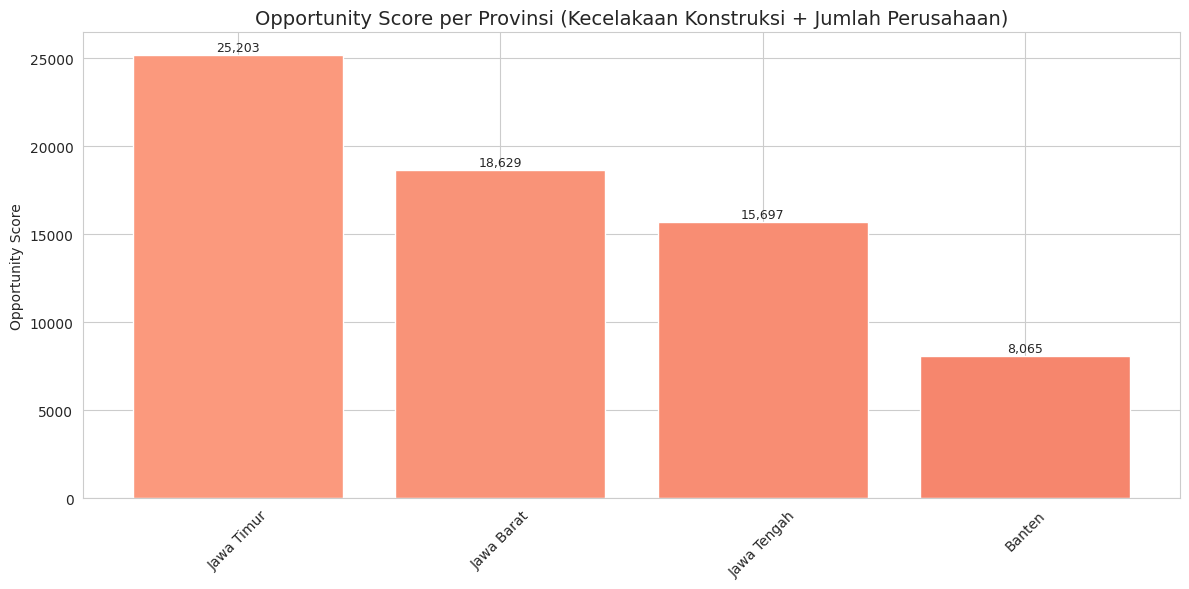

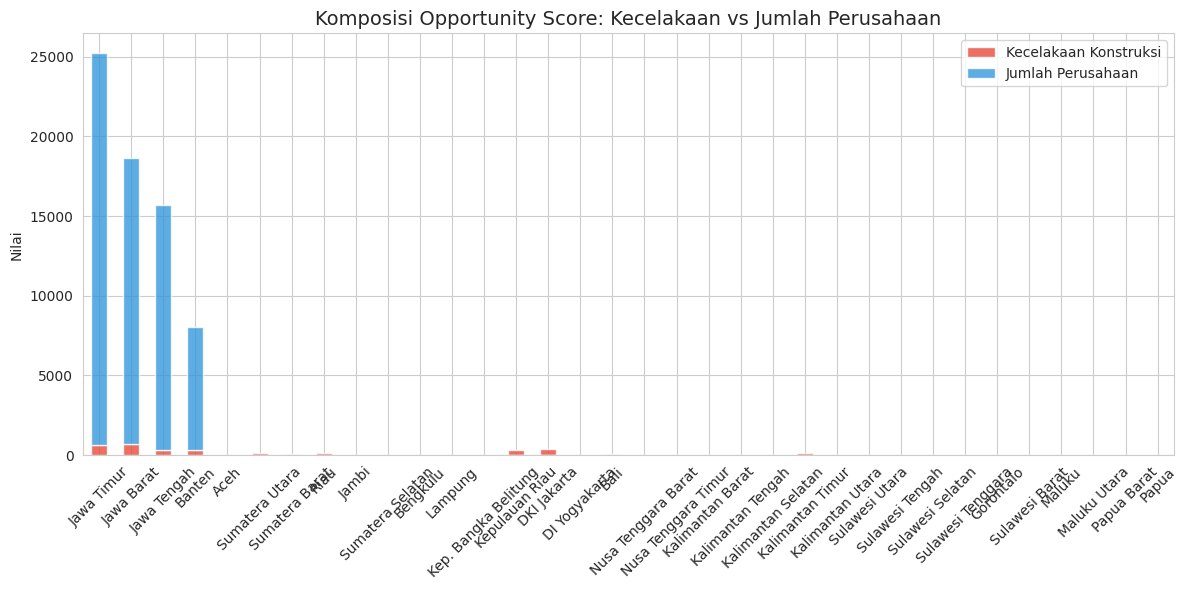

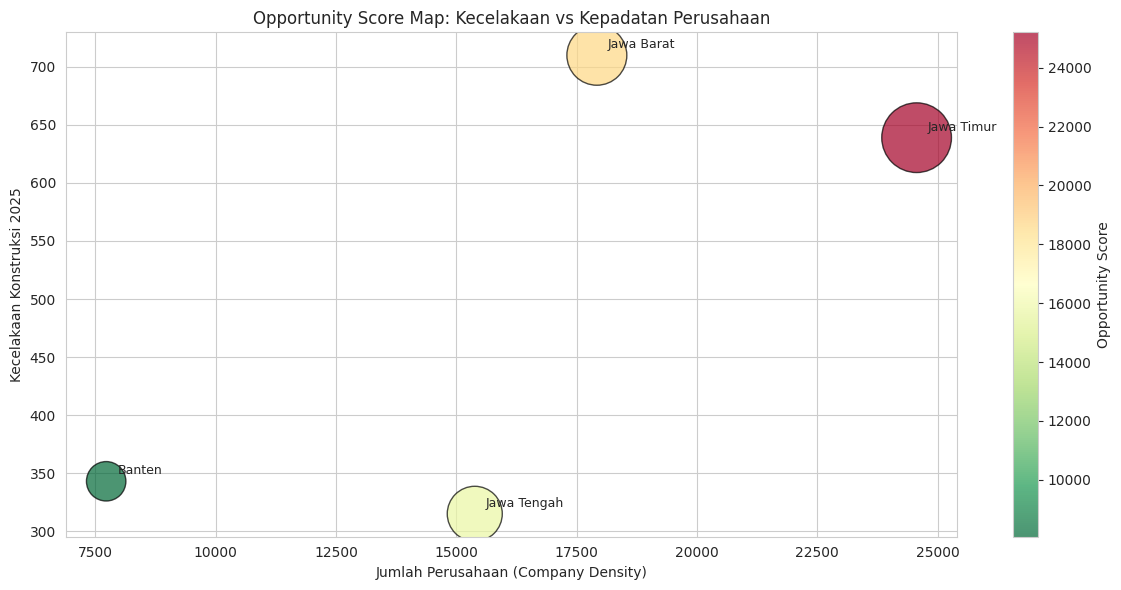

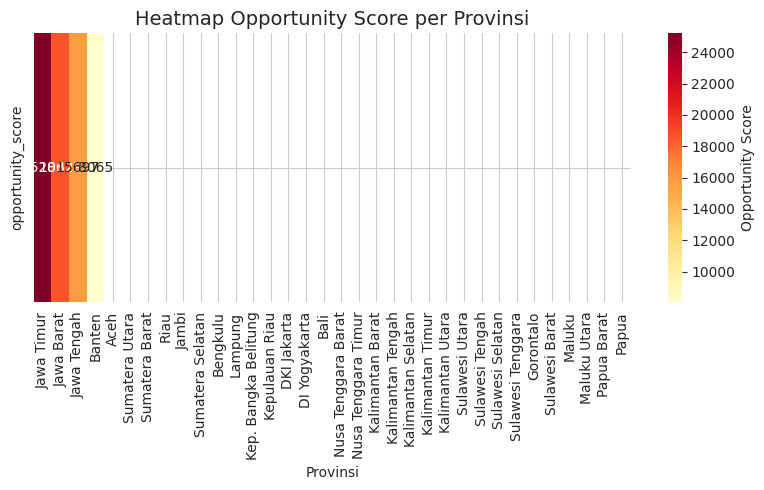


Grafik telah disimpan:
 - opportunity_score_bar.png
 - opportunity_score_stacked.png
 - opportunity_score_scatter.png
 - opportunity_score_heatmap.png

Hasil analisis disimpan ke 'Construction_Risk_Opportunity_Analysis.xlsx'


In [ ]:
# =============================================================================
# CONSTRUCTION RISK OPPORTUNITY ANALYSIS
# Formula: Opportunity Score = Construction Accident Frequency + Construction Company Density
# dimana:
#   - Construction Accident Frequency = jumlah kecelakaan sektor konstruksi tahun 2025
#   - Construction Company Density = jumlah perusahaan konstruksi
# =============================================================================

# Gabungkan data kecelakaan konstruksi dan perusahaan
df_risk = df_kec[["Provinsi", "kecelakaan_konstruksi_2025"]].copy()
df_risk = df_risk.merge(df_perusahaan[["Provinsi", "total_perusahaan"]], on="Provinsi", how="left")

# Hitung Opportunity Score
df_risk["opportunity_score"] = df_risk["kecelakaan_konstruksi_2025"] + df_risk["total_perusahaan"]

#  Urutkan berdasarkan score tertinggi
df_risk = df_risk.sort_values("opportunity_score", ascending=False).reset_index(drop=True)

# Tambahkan kolom peringkat dan kategori risiko-peluang
df_risk["peringkat"] = df_risk["opportunity_score"].rank(ascending=False, method="dense").astype('Int64')

# Kategori berdasarkan kuartil
df_risk["kategori"] = pd.cut(df_risk["opportunity_score"],
                             bins=4,
                             labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"],
                             include_lowest=True)

# Cetak hasil
print("=" * 80)
print("CONSTRUCTION RISK OPPORTUNITY ANALYSIS")
print("Formula: Opportunity Score = Kecelakaan Konstruksi 2025 + Jumlah Perusahaan")
print("=" * 80)
print(df_risk[["peringkat", "Provinsi", "kecelakaan_konstruksi_2025", "total_perusahaan", "opportunity_score", "kategori"]]
      .to_string(index=False))

print("\n" + "=" * 80)
print("STATISTIK OPPORTUNITY SCORE")
print("=" * 80)
print(f"Rata-rata Opportunity Score : {df_risk['opportunity_score'].mean():,.0f}")
print(f"Median Opportunity Score   : {df_risk['opportunity_score'].median():,.0f}")
print(f"Tertinggi                 : {df_risk['opportunity_score'].max():,.0f} ({df_risk.loc[df_risk['opportunity_score'].idxmax(), 'Provinsi']})")
print(f"Terendah                  : {df_risk['opportunity_score'].min():,.0f} ({df_risk.loc[df_risk['opportunity_score'].idxmin(), 'Provinsi']})")

# Kontribusi masing-masing komponen
df_risk["kontribusi_kecelakaan"] = df_risk["kecelakaan_konstruksi_2025"] / df_risk["opportunity_score"] * 100
df_risk["kontribusi_perusahaan"] = df_risk["total_perusahaan"] / df_risk["opportunity_score"] * 100

print("\n" + "=" * 80)
print("KONTRIBUSI KOMPONEN TERHADAP OPPORTUNITY SCORE")
print("=" * 80)
print(df_risk[["Provinsi", "kontribusi_kecelakaan", "kontribusi_perusahaan"]].to_string(index=False))

# =============================================================================
# VISUALISASI
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Bar chart Opportunity Score per provinsi
fig1, ax1 = plt.subplots()
colors = sns.color_palette("Reds_d", len(df_risk))
bars = ax1.bar(df_risk["Provinsi"], df_risk["opportunity_score"], color=colors)
ax1.set_title("Opportunity Score per Provinsi (Kecelakaan Konstruksi + Jumlah Perusahaan)", fontsize=14)
ax1.set_ylabel("Opportunity Score")
ax1.set_xlabel("")
for bar, score in zip(bars, df_risk["opportunity_score"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f"{score:,.0f}",
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("opportunity_score_bar.png", dpi=150)
plt.show()

# 2. Stacked bar: kontribusi kecelakaan vs perusahaan
fig2, ax2 = plt.subplots()
df_stack = df_risk.set_index("Provinsi")[["kecelakaan_konstruksi_2025", "total_perusahaan"]]
df_stack.plot(kind="bar", stacked=True, ax=ax2, color=["#E74C3C", "#3498DB"], alpha=0.8)
ax2.set_title("Komposisi Opportunity Score: Kecelakaan vs Jumlah Perusahaan", fontsize=14)
ax2.set_ylabel("Nilai")
ax2.set_xlabel("")
plt.xticks(rotation=45)
ax2.legend(["Kecelakaan Konstruksi", "Jumlah Perusahaan"])
plt.tight_layout()
plt.savefig("opportunity_score_stacked.png", dpi=150)
plt.show()

# 3. Scatter plot: hubungan kecelakaan dan perusahaan
fig3, ax3 = plt.subplots()
scatter = ax3.scatter(df_risk["total_perusahaan"], df_risk["kecelakaan_konstruksi_2025"],
                      s=df_risk["opportunity_score"]/10, c=df_risk["opportunity_score"],
                      cmap="RdYlGn_r", alpha=0.7, edgecolors="black")
for _, row in df_risk.iterrows():
    ax3.annotate(row["Provinsi"], (row["total_perusahaan"], row["kecelakaan_konstruksi_2025"]),
                 xytext=(8, 5), textcoords="offset points", fontsize=9)
ax3.set_xlabel("Jumlah Perusahaan (Company Density)")
ax3.set_ylabel("Kecelakaan Konstruksi 2025")
ax3.set_title("Opportunity Score Map: Kecelakaan vs Kepadatan Perusahaan")
cbar = plt.colorbar(scatter)
cbar.set_label("Opportunity Score")
plt.tight_layout()
plt.savefig("opportunity_score_scatter.png", dpi=150)
plt.show()

# 4. Heatmap peringkat
fig4, ax4 = plt.subplots(figsize=(8, 5))
rank_matrix = df_risk.set_index("Provinsi")[["opportunity_score"]].T
sns.heatmap(rank_matrix, annot=True, fmt=".0f", cmap="YlOrRd",
            cbar_kws={'label': 'Opportunity Score'}, ax=ax4)
ax4.set_title("Heatmap Opportunity Score per Provinsi", fontsize=14)
plt.tight_layout()
plt.savefig("opportunity_score_heatmap.png", dpi=150)
plt.show()

print("\nGrafik telah disimpan:")
print(" - opportunity_score_bar.png")
print(" - opportunity_score_stacked.png")
print(" - opportunity_score_scatter.png")
print(" - opportunity_score_heatmap.png")

# =============================================================================
# EKSPORT HASIL KE EXCEL
# =============================================================================
with pd.ExcelWriter("Construction_Risk_Opportunity_Analysis.xlsx") as writer:
    df_risk.to_excel(writer, sheet_name="Opportunity_Score", index=False)
print("\nHasil analisis disimpan ke 'Construction_Risk_Opportunity_Analysis.xlsx'")

**B2B Market Prioritization**

B2B MARKET PRIORITIZATION ANALYSIS

--- PRIORITAS PER PROVINSI ---
            Provinsi  prioritas_score              kategori_prioritas  opportunity_score  market_share  risk_density
          Jawa Timur        76.936319 Sales Prioritas (High Priority)            25203.0     37.452544     26.013679
          Jawa Barat        66.810083 Pilot Project (Medium Priority)            18629.0     27.320963     39.622747
         Jawa Tengah        31.457507 Canvassing Sales (Low Priority)            15697.0     23.452818     20.478481
              Banten        30.000000 Canvassing Sales (Low Priority)             8065.0     11.773675     44.418544
                Aceh              NaN Canvassing Sales (Low Priority)                NaN           NaN           NaN
      Sumatera Utara              NaN Canvassing Sales (Low Priority)                NaN           NaN           NaN
      Sumatera Barat              NaN Canvassing Sales (Low Priority)                NaN           NaN           N

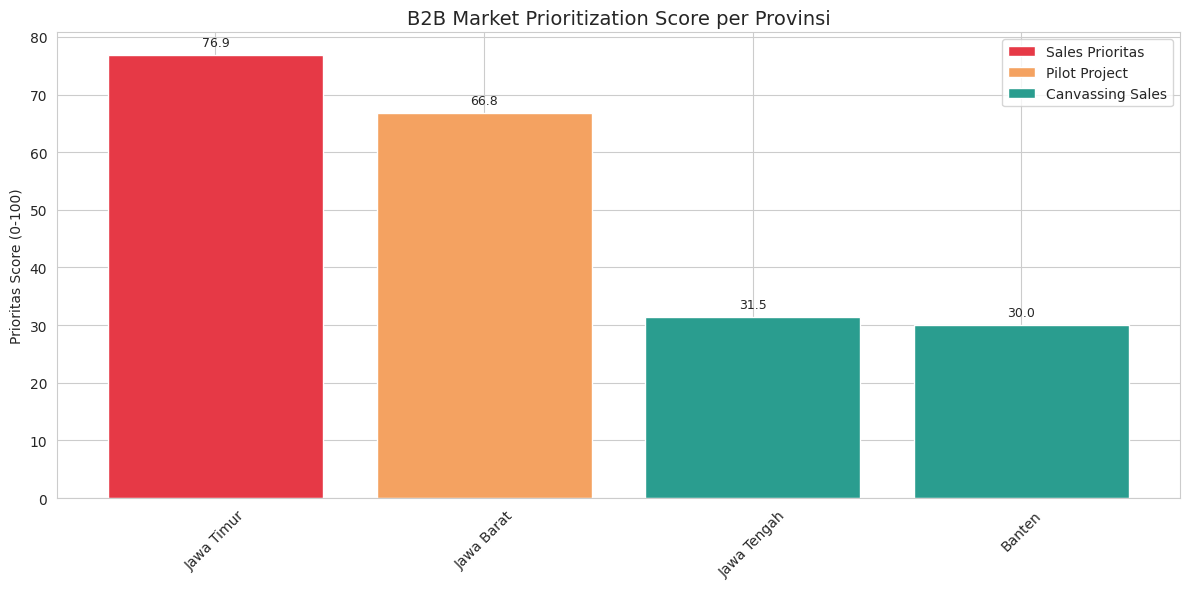

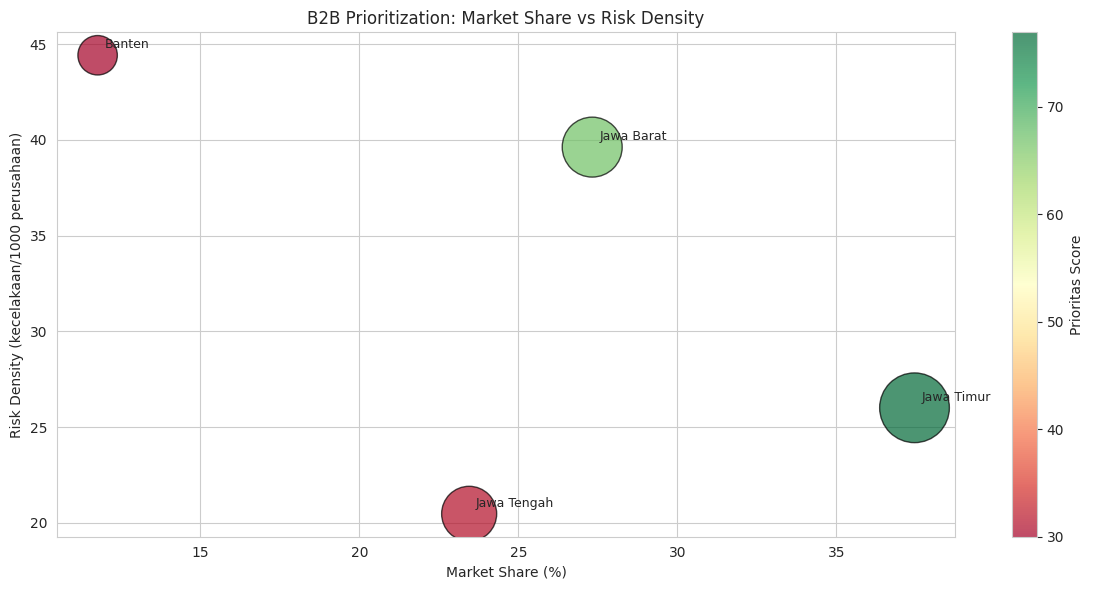

/tmp/ipykernel_918/2820038019.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_kab, y="Kabupaten_Kota", x="Jumlah_Perusahaan", palette="viridis", orient='h')


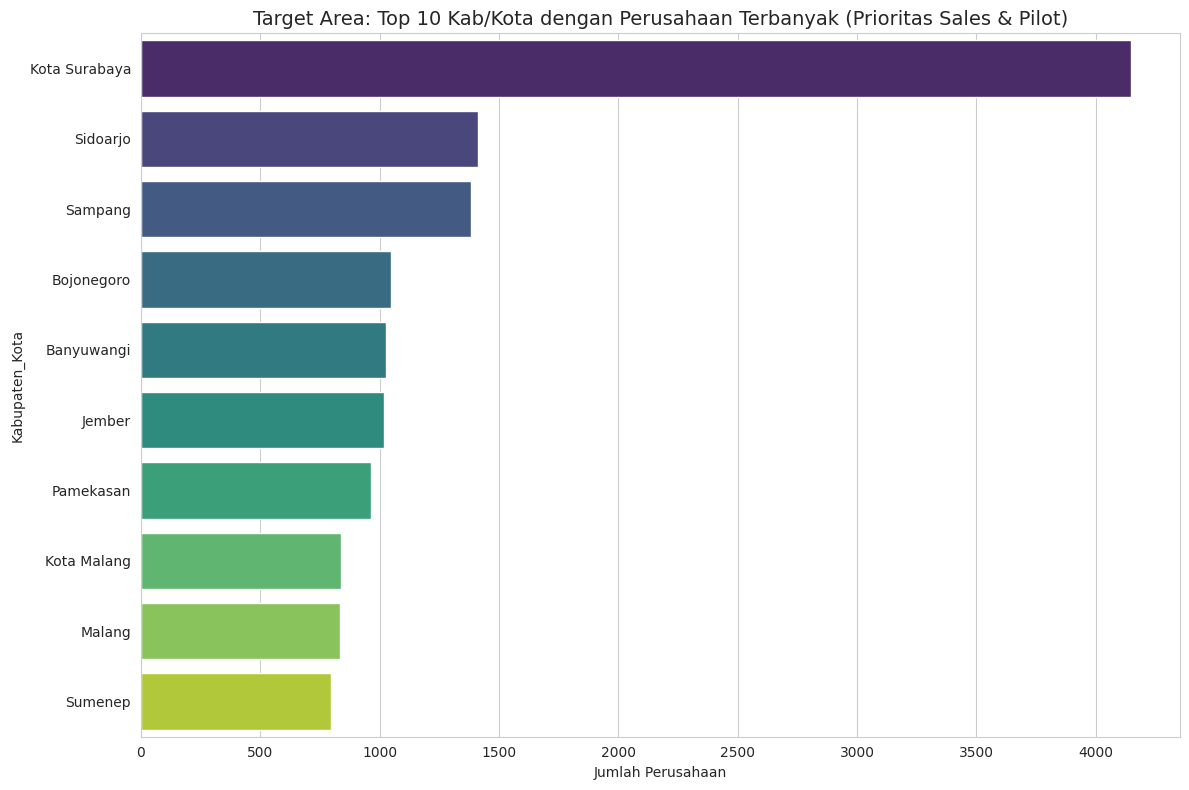


Hasil B2B Market Prioritization disimpan ke 'B2B_Market_Prioritization.xlsx'


In [ ]:
# =============================================================================
# B2B MARKET PRIORITIZATION ANALYSIS
# Tujuan: Menentukan wilayah sales prioritas, daerah pilot project, area canvassing sales
# =============================================================================

# 1. Siapkan data dasar (gabungkan kecelakaan konstruksi 2025 dan jumlah perusahaan)
df_b2b = df_kec[["Provinsi", "kecelakaan_konstruksi_2025"]].copy()
df_b2b = df_b2b.merge(df_perusahaan[["Provinsi", "total_perusahaan"]], on="Provinsi", how="left")

# 2. Hitung metrik pendukung
df_b2b["opportunity_score"] = df_b2b["kecelakaan_konstruksi_2025"] + df_b2b["total_perusahaan"]
df_b2b["risk_density"] = (df_b2b["kecelakaan_konstruksi_2025"] / df_b2b["total_perusahaan"]) * 1000
df_b2b["market_share"] = df_b2b["total_perusahaan"] / df_b2b["total_perusahaan"].sum() * 100
df_b2b["accident_share"] = df_b2b["kecelakaan_konstruksi_2025"] / df_b2b["kecelakaan_konstruksi_2025"].sum() * 100

# 3. Hitung skor prioritas (bobot: 40% opportunity score, 30% market share, 30% risk density)
# Normalisasi setiap metrik ke skala 0-100
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_b2b["score_normalized"] = scaler.fit_transform(df_b2b[["opportunity_score"]])
df_b2b["market_normalized"] = scaler.fit_transform(df_b2b[["market_share"]])
df_b2b["risk_normalized"] = scaler.fit_transform(df_b2b[["risk_density"]])

df_b2b["prioritas_score"] = (0.4 * df_b2b["score_normalized"] +
                              0.3 * df_b2b["market_normalized"] +
                              0.3 * df_b2b["risk_normalized"]) * 100

# 4. Kategorisasi berdasarkan prioritas score
def kategorisasi(score):
    if score >= 70:
        return "Sales Prioritas (High Priority)"
    elif score >= 40:
        return "Pilot Project (Medium Priority)"
    else:
        return "Canvassing Sales (Low Priority)"

df_b2b["kategori_prioritas"] = df_b2b["prioritas_score"].apply(kategorisasi)
df_b2b = df_b2b.sort_values("prioritas_score", ascending=False).reset_index(drop=True)

# 5. Tentukan wilayah spesifik per kategori (bisa sampai level kabupaten/kota)
# Untuk kabupaten/kota, kita ambil dari df_hotspot (asumsikan sudah dibuat)
# Jika belum, kita baca ulang data perusahaan untuk level kabupaten
if 'df_hotspot' not in locals() or df_hotspot.empty:
    # Baca hotspot jika belum ada
    file_perusahaan = "Perusahaan Konstruksi Jawa 2025.xlsx"
    sheets = ["Jatim", "Jateng", "Jawa Barat", "Banten"]
    provinsi_map = {"Jatim": "Jawa Timur", "Jateng": "Jawa Tengah", "Jawa Barat": "Jawa Barat", "Banten": "Banten"}
    list_hotspot = []
    for sheet in sheets:
        df_temp = pd.read_excel(file_perusahaan, sheet_name=sheet, header=1)
        # Convert all column names to string type for robust checking
        df_temp.columns = df_temp.columns.astype(str)
        kab_col = "Kabupaten/Kota" if "Kabupaten/Kota" in df_temp.columns else df_temp.columns[1]

        if "Jumlah 2" in df_temp.columns:
            jumlah_col = "Jumlah 2"
        elif "Jumlah" in df_temp.columns:
            jumlah_col = "Jumlah"
        else:
            # Fallback for sheets like 'Banten' where total is in a numeric-named column, often the last one.
            jumlah_col = df_temp.columns[-1]

        df_hot = df_temp[df_temp[kab_col].notna()].copy()
        df_hot = df_hot[~df_hot[kab_col].isin(["Jumlah", "Total", "Jumlah ", "Total "])]
        for _, row in df_hot.iterrows():
            list_hotspot.append({
                "Provinsi": provinsi_map[sheet],
                "Kabupaten_Kota": str(row[kab_col]).strip(),
                "Jumlah_Perusahaan": row[jumlah_col] if pd.notna(row[jumlah_col]) else 0
            })
    df_hotspot = pd.DataFrame(list_hotspot)
    df_hotspot = df_hotspot.sort_values("Jumlah_Perusahaan", ascending=False)

# Gabungkan kabupaten/kota ke dalam prioritas berdasarkan provinsinya
df_hotspot = df_hotspot.merge(df_b2b[["Provinsi", "kategori_prioritas"]], on="Provinsi", how="left")

# 6. Cetak hasil
print("=" * 80)
print("B2B MARKET PRIORITIZATION ANALYSIS")
print("=" * 80)
print("\n--- PRIORITAS PER PROVINSI ---")
print(df_b2b[["Provinsi", "prioritas_score", "kategori_prioritas", "opportunity_score", "market_share", "risk_density"]]
      .to_string(index=False))

print("\n--- RINGKASAN KATEGORI ---")
for kat in ["Sales Prioritas (High Priority)", "Pilot Project (Medium Priority)", "Canvassing Sales (Low Priority)"]:
    prov_list = df_b2b[df_b2b["kategori_prioritas"] == kat]["Provinsi"].tolist()
    print(f"{kat}: {', '.join(prov_list) if prov_list else 'Tidak ada'}")

print("\n--- DAFTAR WILAYAH PER KATEGORI (KABUPATEN/KOTA TOP 3 PER PROVINSI) ---")
for kat in ["Sales Prioritas (High Priority)", "Pilot Project (Medium Priority)", "Canvassing Sales (Low Priority)"]:
    print(f"\n### {kat} ###")
    prov_kat = df_b2b[df_b2b["kategori_prioritas"] == kat]["Provinsi"].tolist()
    for prov in prov_kat:
        top_kab = df_hotspot[df_hotspot["Provinsi"] == prov].head(3)
        if not top_kab.empty:
            print(f"\n{prov}:")
            for _, row in top_kab.iterrows():
                print(f"  - {row['Kabupaten_Kota']} ({row['Jumlah_Perusahaan']:,} perusahaan)")

# =============================================================================
# VISUALISASI
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Bar chart prioritas score per provinsi dengan warna kategori
fig1, ax1 = plt.subplots()
colors = {'Sales Prioritas (High Priority)': '#E63946',
          'Pilot Project (Medium Priority)': '#F4A261',
          'Canvassing Sales (Low Priority)': '#2A9D8F'}
bar_colors = [colors[cat] for cat in df_b2b["kategori_prioritas"]]
bars = ax1.bar(df_b2b["Provinsi"], df_b2b["prioritas_score"], color=bar_colors)
ax1.set_title("B2B Market Prioritization Score per Provinsi", fontsize=14)
ax1.set_ylabel("Prioritas Score (0-100)")
ax1.set_xlabel("")
for bar, score in zip(bars, df_b2b["prioritas_score"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{score:.1f}",
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
# Tambahkan legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors['Sales Prioritas (High Priority)'], label='Sales Prioritas'),
                   Patch(facecolor=colors['Pilot Project (Medium Priority)'], label='Pilot Project'),
                   Patch(facecolor=colors['Canvassing Sales (Low Priority)'], label='Canvassing Sales')]
ax1.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig("b2b_prioritas_score.png", dpi=150)
plt.show()

# 2. Bubble chart: market share vs risk density, ukuran bubble = opportunity score
fig2, ax2 = plt.subplots()
size = df_b2b["opportunity_score"] / 10
scatter = ax2.scatter(df_b2b["market_share"], df_b2b["risk_density"],
                      s=size, c=df_b2b["prioritas_score"], cmap="RdYlGn", alpha=0.7, edgecolors="black")
for _, row in df_b2b.iterrows():
    ax2.annotate(row["Provinsi"], (row["market_share"], row["risk_density"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=9)
ax2.set_xlabel("Market Share (%)")
ax2.set_ylabel("Risk Density (kecelakaan/1000 perusahaan)")
ax2.set_title("B2B Prioritization: Market Share vs Risk Density")
cbar = plt.colorbar(scatter)
cbar.set_label("Prioritas Score")
plt.tight_layout()
plt.savefig("b2b_bubble_chart.png", dpi=150)
plt.show()

# 3. Peta sederhana (bar horizontal) untuk top 10 kabupaten/kota berdasarkan kategori prioritas
fig3, ax3 = plt.subplots(figsize=(12, 8))
# Ambil top 10 kab/kota dari daerah dengan prioritas tinggi
top_kab = df_hotspot[df_hotspot["Provinsi"].isin(df_b2b[df_b2b["kategori_prioritas"]=="Sales Prioritas (High Priority)"]["Provinsi"])].head(10)
if len(top_kab) < 10:
    top_kab = pd.concat([top_kab, df_hotspot[df_hotspot["Provinsi"].isin(df_b2b[df_b2b["kategori_prioritas"]=="Pilot Project (Medium Priority)"]["Provinsi"])].head(10 - len(top_kab))])
sns.barplot(data=top_kab, y="Kabupaten_Kota", x="Jumlah_Perusahaan", palette="viridis", orient='h')
ax3.set_title("Target Area: Top 10 Kab/Kota dengan Perusahaan Terbanyak (Prioritas Sales & Pilot)", fontsize=14)
ax3.set_xlabel("Jumlah Perusahaan")
plt.tight_layout()
plt.savefig("b2b_target_areas.png", dpi=150)
plt.show()

# =============================================================================
# EKSPORT HASIL KE EXCEL
# =============================================================================
with pd.ExcelWriter("B2B_Market_Prioritization.xlsx") as writer:
    df_b2b.to_excel(writer, sheet_name="Prioritas Provinsi", index=False)
    df_hotspot[df_hotspot["Provinsi"].isin(df_b2b["Provinsi"])].to_excel(writer, sheet_name="Prioritas Kab_Kota", index=False)
print("\nHasil B2B Market Prioritization disimpan ke 'B2B_Market_Prioritization.xlsx'")


Kategori yang tersedia: ['Sales Prioritas (High Priority)' 'Pilot Project (Medium Priority)'
 'Canvassing Sales (Low Priority)']
Provinsi Sales Prioritas: ['Jawa Timur']
Provinsi Pilot Project: ['Jawa Barat']


/tmp/ipykernel_918/1444695356.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_target_hotspot, y="Kabupaten_Kota", x="Jumlah_Perusahaan",


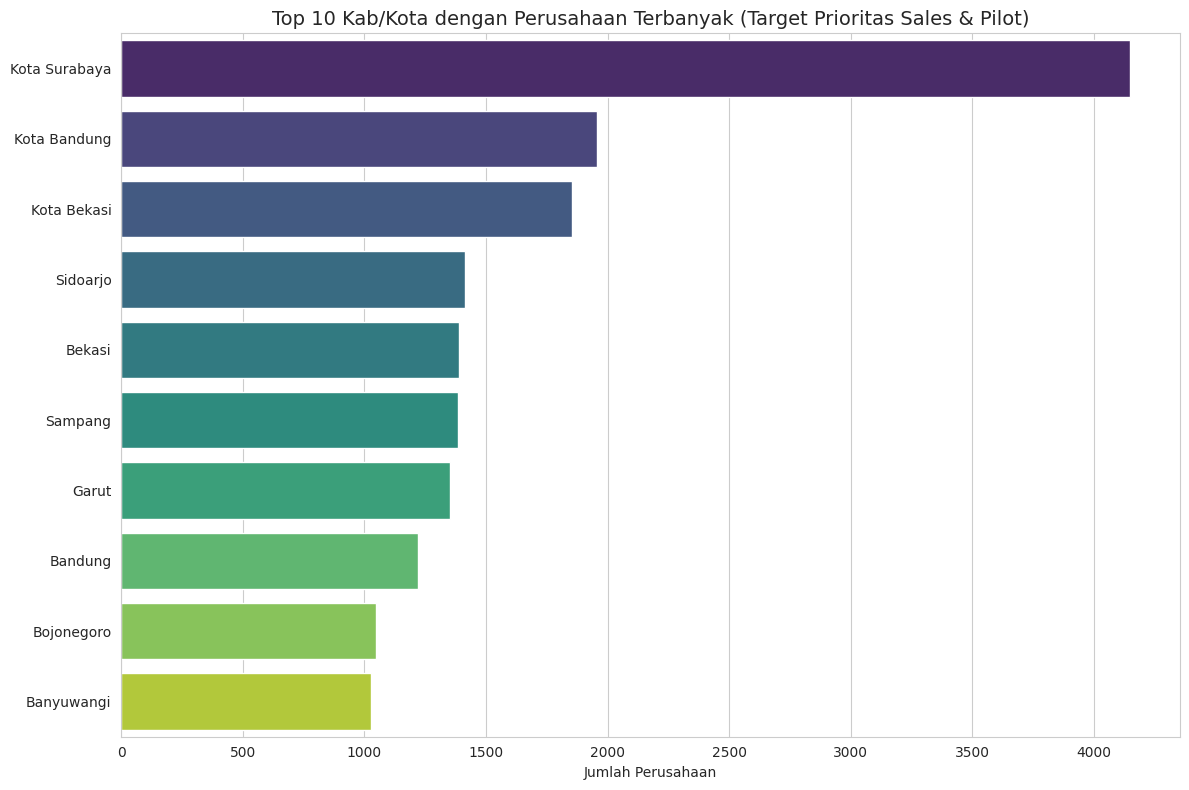

In [ ]:
# =============================================================================
# PERBAIKAN: VISUALISASI TOP 10 KABUPATEN/KOTA UNTUK SALES PRIORITAS & PILOT
# =============================================================================

# Ensure df_hotspot and df_b2b are available from previous cells
# If df_hotspot is empty for some reason, the notebook flow has a deeper issue.
# We assume it has been populated by iCzN1GmA8Vbi and E1vyh8Cz8bNa, and further categorized by Y8idy5QdYRYk.

# Clean 'Provinsi' column in both dataframes
df_hotspot["Provinsi"] = df_hotspot["Provinsi"].str.strip()
df_b2b["Provinsi"] = df_b2b["Provinsi"].str.strip()

# Ensure only one 'kategori_prioritas' column in df_hotspot by explicitly dropping all known variants
for col in ['kategori_prioritas', 'kategori_prioritas_x', 'kategori_prioritas_y']:
    if col in df_hotspot.columns:
        df_hotspot = df_hotspot.drop(columns=[col])

# Merge kategori_prioritas from df_b2b into df_hotspot
# This merge should now be clean as any conflicting column names have been dropped
df_hotspot = df_hotspot.merge(df_b2b[["Provinsi", "kategori_prioritas"]], on="Provinsi", how="left")

# Cek kategori prioritas yang tersedia
kategori_tersedia = df_b2b["kategori_prioritas"].unique()
print("Kategori yang tersedia:", kategori_tersedia)

# Tentukan provinsi untuk prioritas sales dan pilot
prov_sales = df_b2b[df_b2b["kategori_prioritas"] == "Sales Prioritas (High Priority)"]["Provinsi"].tolist()
prov_pilot = df_b2b[df_b2b["kategori_prioritas"] == "Pilot Project (Medium Priority)"]["Provinsi"].tolist()

print(f"Provinsi Sales Prioritas: {prov_sales}")
print(f"Provinsi Pilot Project: {prov_pilot}")

# Gabungkan provinsi yang akan ditampilkan (prioritaskan sales, lalu pilot)
prov_target = prov_sales + prov_pilot

if prov_target:
    # Filter hotspot berdasarkan provinsi target dan pastikan kategori_prioritas tidak NaN
    df_target_hotspot = df_hotspot[df_hotspot["Provinsi"].isin(prov_target) & df_hotspot["kategori_prioritas"].notna()]

    if df_target_hotspot.empty:
        print("Tidak ada kab/kota dari provinsi target dengan kategori prioritas yang jelas. Menggunakan top 10 kab/kota dari semua provinsi sebagai alternatif.")
        df_target_hotspot = df_hotspot.sort_values("Jumlah_Perusahaan", ascending=False).head(10) # Fallback to general top 10 if specific filter fails
    else:
        # Ambil top 10 dari gabungan provinsi target, sorted by Jumlah_Perusahaan
        df_target_hotspot = df_target_hotspot.sort_values("Jumlah_Perusahaan", ascending=False).head(10)

    # Visualisasi
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=df_target_hotspot, y="Kabupaten_Kota", x="Jumlah_Perusahaan",
                palette="viridis", orient='h')
    ax.set_title("Top 10 Kab/Kota dengan Perusahaan Terbanyak (Target Prioritas Sales & Pilot)", fontsize=14)
    ax.set_xlabel("Jumlah Perusahaan")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig("b2b_target_areas.png", dpi=150)
    plt.show()
else:
    print("Tidak ada provinsi dengan kategori Sales Prioritas atau Pilot Project. Semua provinsi masuk Canvassing Sales.")
    print("Menampilkan top 10 kab/kota dari seluruh wilayah untuk referensi canvassing.")
    df_all_top = df_hotspot.sort_values("Jumlah_Perusahaan", ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=df_all_top, y="Kabupaten_Kota", x="Jumlah_Perusahaan",
                palette="coolwarm", orient='h')
    ax.set_title("Top 10 Kab/Kota dengan Perusahaan Terbanyak (Canvassing Area)", fontsize=14)
    ax.set_xlabel("Jumlah Perusahaan")
    plt.tight_layout()
    plt.savefig("b2b_canvassing_areas.png", dpi=150)
    plt.show()


**REGIONAL CONSTRUCTION HOTSPOT ANALYSIS**

REGIONAL CONSTRUCTION HOTSPOT ANALYSIS

--- 1. HOTSPOT KONSTRUKSI (Kepadatan Perusahaan) ---
Total kab/kota dianalisis: 104

Distribusi tingkat hotspot:
kategori_hotspot
Rendah            4
Sedang           27
Tinggi           42
Sangat Tinggi    16
Hotspot Utama    15
Name: count, dtype: int64

Top 10 kab/kota dengan jumlah perusahaan terbanyak:
        Kabupaten_Kota    Provinsi  Jumlah_Perusahaan kategori_hotspot
         Kota Surabaya  Jawa Timur               4146    Hotspot Utama
             Tangerang      Banten               2093    Hotspot Utama
          Kota Bandung  Jawa Barat               1956    Hotspot Utama
           Kota Bekasi  Jawa Barat               1854    Hotspot Utama
        Kota Tangerang      Banten               1516    Hotspot Utama
         Kota Semarang Jawa Tengah               2259    Hotspot Utama
Kota Tangerang Selatan      Banten               1337    Hotspot Utama
                Bekasi  Jawa Barat               1387    Hotspot Utama
            

/tmp/ipykernel_918/1708882379.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hotspot, y="Kabupaten_Kota", x="Jumlah_Perusahaan", palette="rocket", orient='h')


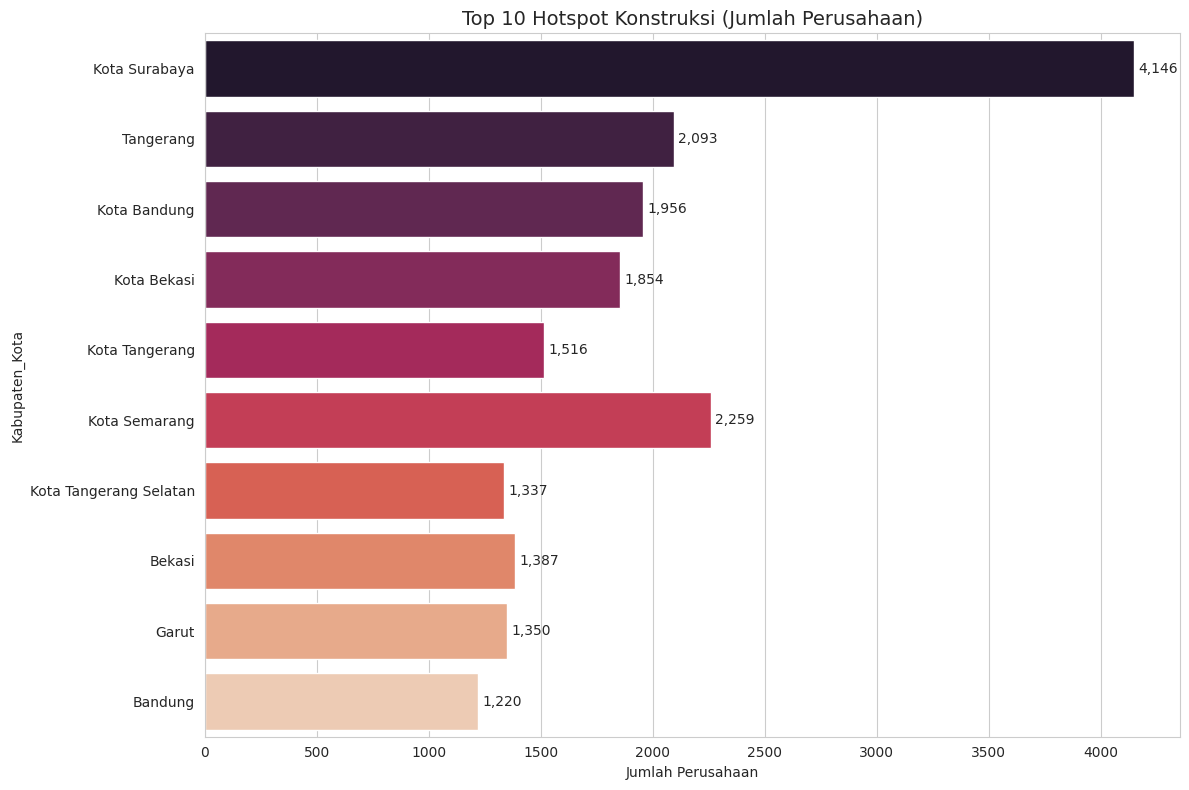

/tmp/ipykernel_918/1708882379.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_aktivitas, y="Kabupaten_Kota", x="aktivitas_score", palette="viridis", orient='h')


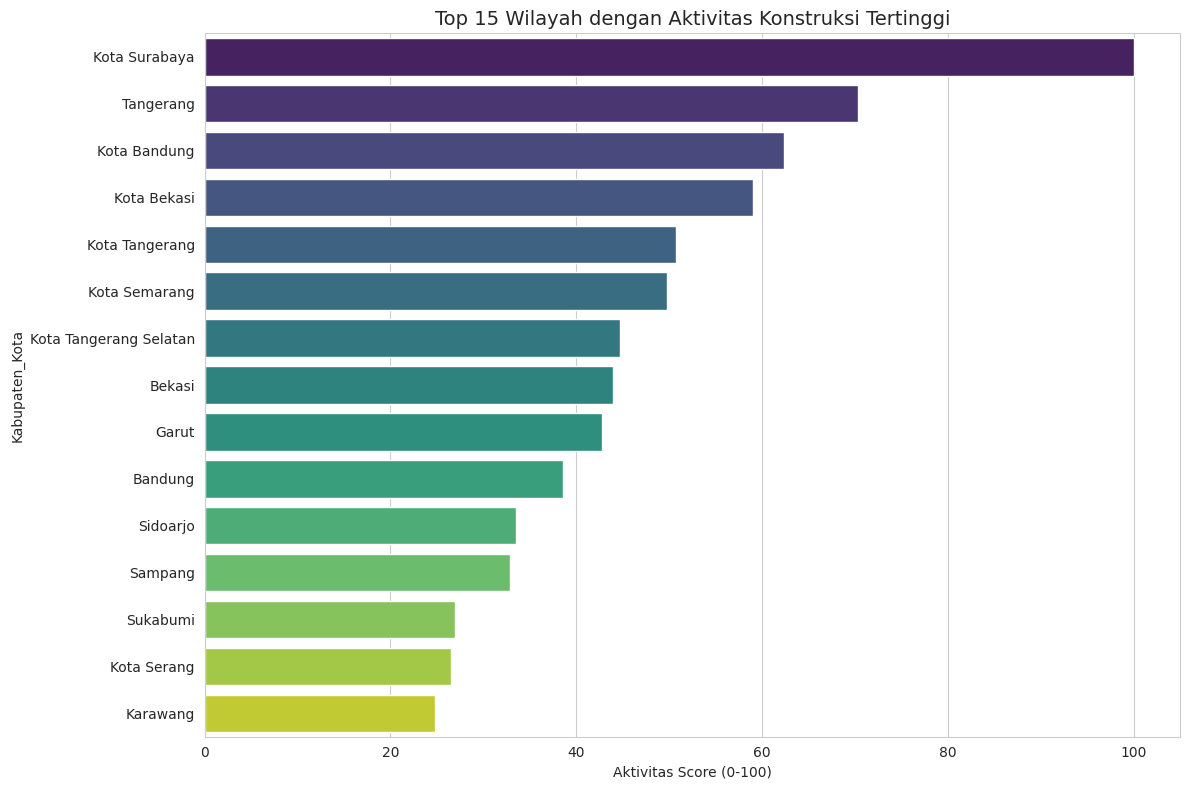

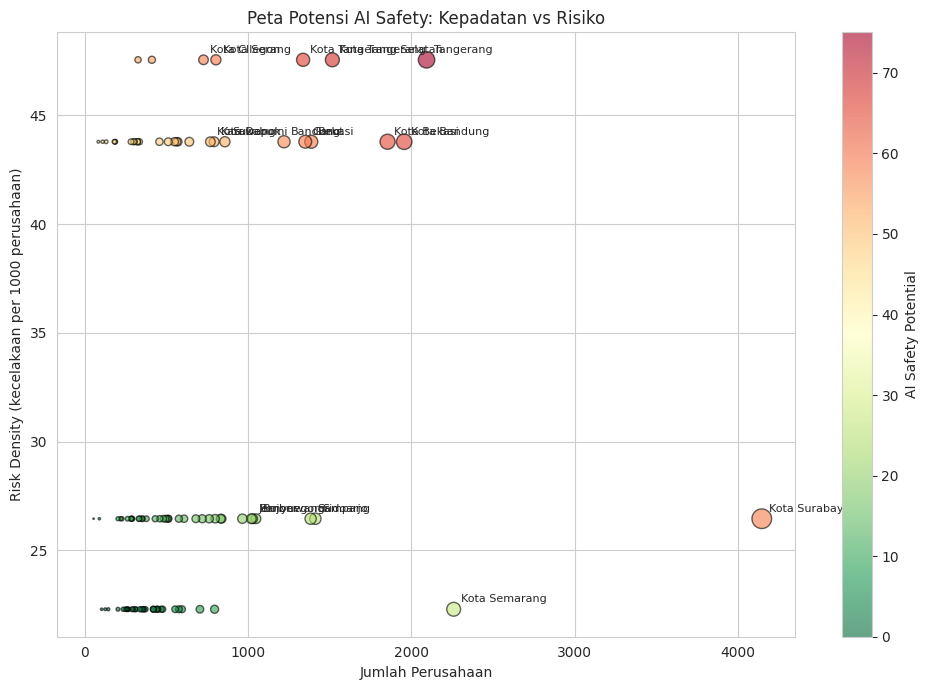

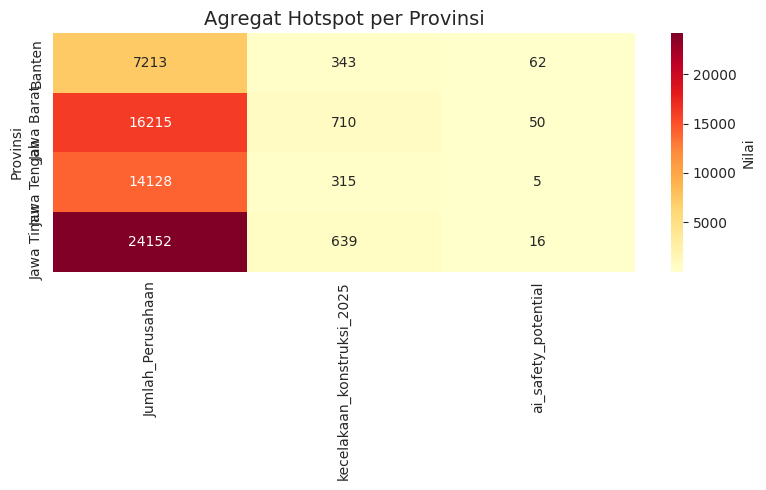

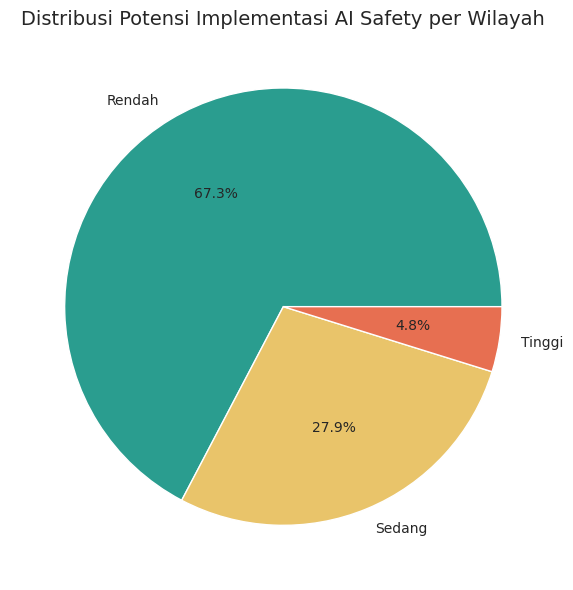


Grafik telah disimpan:
 - hotspot_top10_companies.png
 - hotspot_aktivitas_score.png
 - hotspot_ai_safety_map.png
 - hotspot_province_heatmap.png
 - hotspot_ai_pie.png

Hasil analisis hotspot disimpan ke 'Regional_Construction_Hotspot.xlsx'


In [ ]:
# =============================================================================
# REGIONAL CONSTRUCTION HOTSPOT ANALYSIS
# Tujuan:
#   1. Hotspot konstruksi (kepadatan perusahaan)
#   2. Wilayah aktivitas konstruksi tinggi (kombinasi perusahaan & kecelakaan)
#   3. Potensi implementasi AI safety (risiko tinggi + kepadatan tinggi)
# =============================================================================

if 'df_hotspot' not in locals() or df_hotspot.empty:
    print("Membaca data hotspot dari file perusahaan...")
    file_perusahaan = "Perusahaan Konstruksi Jawa 2025.xlsx"
    sheets = ["Jatim", "Jateng", "Jawa Barat", "Banten"]
    provinsi_map = {"Jatim": "Jawa Timur", "Jateng": "Jawa Tengah",
                    "Jawa Barat": "Jawa Barat", "Banten": "Banten"}
    list_hotspot = []
    for sheet in sheets:
        df_temp = pd.read_excel(file_perusahaan, sheet_name=sheet, header=1)
        # Convert all column names to string type for robust checking
        df_temp.columns = df_temp.columns.astype(str)
        kab_col = "Kabupaten/Kota" if "Kabupaten/Kota" in df_temp.columns else df_temp.columns[1]

        if "Jumlah 2" in df_temp.columns:
            jumlah_col = "Jumlah 2"
        elif "Jumlah" in df_temp.columns:
            jumlah_col = "Jumlah"
        else:
            # Fallback for sheets like 'Banten' where total is in a numeric-named column, often the last one.
            jumlah_col = df_temp.columns[-1]

        df_hot = df_temp[df_temp[kab_col].notna()].copy()
        df_hot = df_hot[~df_hot[kab_col].isin(["Jumlah", "Total", "Jumlah ", "Total "])]
        for _, row in df_hot.iterrows():
            list_hotspot.append({
                "Provinsi": provinsi_map[sheet],
                "Kabupaten_Kota": str(row[kab_col]).strip(),
                "Jumlah_Perusahaan": row[jumlah_col] if pd.notna(row[jumlah_col]) else 0
            })
    df_hotspot = pd.DataFrame(list_hotspot)
    df_hotspot = df_hotspot.sort_values("Jumlah_Perusahaan", ascending=False)

if 'df_kec' not in locals() or df_kec.empty:
    print("Membaca data kecelakaan konstruksi...")
    file_kec = "Kecelakaan kerja 3 tahun.xlsx"
    df_kec_raw = pd.read_excel(file_kec, sheet_name="Sheet1", header=3)
    df_kec_raw = df_kec_raw.dropna(subset=["Provinsi"], how="all")
    df_kec = df_kec_raw[df_kec_raw["Provinsi"].notna() & (df_kec_raw["Provinsi"] != "Jumlah")].copy()
    # Ambil kolom kecelakaan konstruksi
    # Assuming the correct column index for 2025 is 9, but it might vary based on data changes
    # It's better to explicitly map or find the column if possible
    kolom_2025 = df_kec_raw.columns[9]  # 'Jasa Konstruksi.1' in current df_kec_raw
    df_kec = df_kec[["Provinsi", kolom_2025]].rename(columns={kolom_2025: "kecelakaan_konstruksi_2025"})
    df_kec["Provinsi"] = df_kec["Provinsi"].str.strip()

# 1. Hotspot konstruksi (kepadatan perusahaan) - level kab/kota
df_hotspot["kategori_hotspot"] = pd.cut(df_hotspot["Jumlah_Perusahaan"],
                                         bins=[0, 100, 300, 600, 1000, 10000],
                                         labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi", "Hotspot Utama"])

# 2. Tambahkan data kecelakaan provinsi ke setiap kab/kota (asumsi proporsional)
df_hotspot = df_hotspot.merge(df_kec, on="Provinsi", how="left")

# 3. Hitung risk density per kab/kota (estimasi: kecelakaan provinsi * (perusahaan kab/total perusahaan provinsi))
df_prov_total = df_hotspot.groupby("Provinsi")["Jumlah_Perusahaan"].sum().reset_index(name="total_perusahaan_prov")
df_hotspot = df_hotspot.merge(df_prov_total, on="Provinsi", how="left")
df_hotspot["estimasi_kecelakaan_kab"] = (df_hotspot["Jumlah_Perusahaan"] / df_hotspot["total_perusahaan_prov"]) * df_hotspot["kecelakaan_konstruksi_2025"]
df_hotspot["risk_density_kab"] = (df_hotspot["estimasi_kecelakaan_kab"] / df_hotspot["Jumlah_Perusahaan"]) * 1000

# 4. Skor aktivitas konstruksi (kombinasi jumlah perusahaan + estimasi kecelakaan)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_hotspot["perusahaan_norm"] = scaler.fit_transform(df_hotspot[["Jumlah_Perusahaan"]])
df_hotspot["kecelakaan_norm"] = scaler.fit_transform(df_hotspot[["estimasi_kecelakaan_kab"]])
df_hotspot["aktivitas_score"] = (df_hotspot["perusahaan_norm"] + df_hotspot["kecelakaan_norm"]) * 50  # skala 0-100

# 5. Potensi AI safety: kombinasi risk density tinggi + jumlah perusahaan tinggi
df_hotspot["risk_norm"] = scaler.fit_transform(df_hotspot[["risk_density_kab"]])
df_hotspot["ai_safety_potential"] = (df_hotspot["perusahaan_norm"] + df_hotspot["risk_norm"]) * 50
df_hotspot["kategori_ai"] = pd.cut(df_hotspot["ai_safety_potential"],
                                   bins=[0, 30, 60, 100],
                                   labels=["Rendah", "Sedang", "Tinggi"])

# 6. Tentukan hotspot utama (top 10 berdasarkan aktivitas score)
df_hotspot = df_hotspot.sort_values("aktivitas_score", ascending=False)
top_hotspot = df_hotspot.head(10)

# =============================================================================
# CETAK HASIL ANALISIS
# =============================================================================
print("=" * 80)
print("REGIONAL CONSTRUCTION HOTSPOT ANALYSIS")
print("=" * 80)

print("\n--- 1. HOTSPOT KONSTRUKSI (Kepadatan Perusahaan) ---")
print(f"Total kab/kota dianalisis: {len(df_hotspot)}")
print("\nDistribusi tingkat hotspot:")
print(df_hotspot["kategori_hotspot"].value_counts().sort_index())

print("\nTop 10 kab/kota dengan jumlah perusahaan terbanyak:")
print(df_hotspot[["Kabupaten_Kota", "Provinsi", "Jumlah_Perusahaan", "kategori_hotspot"]].head(10).to_string(index=False))

print("\n--- 2. WILAYAH DENGAN AKTIVITAS KONSTRUKSI TINGGI (Aktivitas Score) ---")
print("Aktivitas Score = (Normalized Perusahaan + Normalized Kecelakaan) * 50")
print("\nTop 10 wilayah dengan aktivitas konstruksi tertinggi:")
print(df_hotspot[["Kabupaten_Kota", "Provinsi", "aktivitas_score", "Jumlah_Perusahaan", "estimasi_kecelakaan_kab"]]
      .head(10).round(2).to_string(index=False))

print("\n--- 3. POTENSI IMPLEMENTASI AI SAFETY ---")
print("AI Safety Potential = (Normalized Perusahaan + Normalized Risk Density) * 50")
print("\nWilayah dengan potensi AI safety TERTINGGI (prioritas implementasi):")
df_ai_high = df_hotspot[df_hotspot["kategori_ai"] == "Tinggi"].sort_values("ai_safety_potential", ascending=False)
print(df_ai_high[["Kabupaten_Kota", "Provinsi", "ai_safety_potential", "risk_density_kab", "Jumlah_Perusahaan"]]
      .head(10).round(2).to_string(index=False))

print("\nRekomendasi implementasi AI safety berdasarkan kategori:")
for kat in ["Tinggi", "Sedang", "Rendah"]:
    jumlah = len(df_hotspot[df_hotspot["kategori_ai"] == kat])
    print(f"  - {kat}: {jumlah} wilayah")

# =============================================================================
# VISUALISASI
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Top 10 hotspot (bar horizontal)
fig1, ax1 = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_hotspot, y="Kabupaten_Kota", x="Jumlah_Perusahaan", palette="rocket", orient='h')
ax1.set_title("Top 10 Hotspot Konstruksi (Jumlah Perusahaan)", fontsize=14)
ax1.set_xlabel("Jumlah Perusahaan")
for i, v in enumerate(top_hotspot["Jumlah_Perusahaan"]):
    ax1.text(v + 20, i, f"{v:,.0f}", va='center')
plt.tight_layout()
plt.savefig("hotspot_top10_companies.png", dpi=150)
plt.show()

# 2. Aktivitas Score per wilayah (top 15)
fig2, ax2 = plt.subplots(figsize=(12, 8))
top15_aktivitas = df_hotspot.head(15)
sns.barplot(data=top15_aktivitas, y="Kabupaten_Kota", x="aktivitas_score", palette="viridis", orient='h')
ax2.set_title("Top 15 Wilayah dengan Aktivitas Konstruksi Tertinggi", fontsize=14)
ax2.set_xlabel("Aktivitas Score (0-100)")
plt.tight_layout()
plt.savefig("hotspot_aktivitas_score.png", dpi=150)
plt.show()

# 3. Scatter plot: Jumlah Perusahaan vs Risk Density (warna berdasarkan potensi AI)
fig3, ax3 = plt.subplots(figsize=(10, 7))
scatter = ax3.scatter(df_hotspot["Jumlah_Perusahaan"], df_hotspot["risk_density_kab"],
                      c=df_hotspot["ai_safety_potential"], cmap="RdYlGn_r",
                      s=df_hotspot["aktivitas_score"]*2, alpha=0.6, edgecolors="black")
# Label hanya untuk top 20
top20 = df_hotspot.head(20)
for _, row in top20.iterrows():
    ax3.annotate(row["Kabupaten_Kota"], (row["Jumlah_Perusahaan"], row["risk_density_kab"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=8)
ax3.set_xlabel("Jumlah Perusahaan")
ax3.set_ylabel("Risk Density (kecelakaan per 1000 perusahaan)")
ax3.set_title("Peta Potensi AI Safety: Kepadatan vs Risiko")
cbar = plt.colorbar(scatter)
cbar.set_label("AI Safety Potential")
plt.tight_layout()
plt.savefig("hotspot_ai_safety_map.png", dpi=150)
plt.show()

# 4. Heatmap provinsi (agregat)
df_prov_agg = df_hotspot.groupby("Provinsi").agg({
    "Jumlah_Perusahaan": "sum",
    "kecelakaan_konstruksi_2025": "first",
    "ai_safety_potential": "mean"
}).reset_index()
fig4, ax4 = plt.subplots(figsize=(8, 5))
sns.heatmap(df_prov_agg.set_index("Provinsi")[["Jumlah_Perusahaan", "kecelakaan_konstruksi_2025", "ai_safety_potential"]],
            annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Nilai'})
ax4.set_title("Agregat Hotspot per Provinsi", fontsize=14)
plt.tight_layout()
plt.savefig("hotspot_province_heatmap.png", dpi=150)
plt.show()

# 5. Pie chart kategori potensi AI safety
fig5, ax5 = plt.subplots()
kategori_counts = df_hotspot["kategori_ai"].value_counts()
colors_pie = ["#2A9D8F", "#E9C46A", "#E76F51"]
wedges, texts, autotexts = ax5.pie(kategori_counts, labels=kategori_counts.index, autopct='%1.1f%%', colors=colors_pie)
ax5.set_title("Distribusi Potensi Implementasi AI Safety per Wilayah", fontsize=14)
plt.tight_layout()
plt.savefig("hotspot_ai_pie.png", dpi=150)
plt.show()

print("\nGrafik telah disimpan:")
print(" - hotspot_top10_companies.png")
print(" - hotspot_aktivitas_score.png")
print(" - hotspot_ai_safety_map.png")
print(" - hotspot_province_heatmap.png")
print(" - hotspot_ai_pie.png")

# =============================================================================
# EKSPORT HASIL
# =============================================================================
with pd.ExcelWriter("Regional_Construction_Hotspot.xlsx") as writer:
    df_hotspot.to_excel(writer, sheet_name="Hotspot_Kab_Kota", index=False)
    df_prov_agg.to_excel(writer, sheet_name="Agregat_Provinsi", index=False)
print("\nHasil analisis hotspot disimpan ke 'Regional_Construction_Hotspot.xlsx'")


**Segmentasi pasar**

MARKET SEGMENTATION ANALYSIS
Median kecelakaan konstruksi: 26
Median jumlah perusahaan: 16650
Kategori: High = nilai di atas median

--- SEGMENTASI PER PROVINSI ---
            Provinsi  kecelakaan_konstruksi_2025  total_perusahaan            segment
          Jawa Barat                         710           17919.0   High Opportunity
          Jawa Timur                         639           24564.0   High Opportunity
         DKI Jakarta                         358               NaN Medium Opportunity
              Banten                         343            7722.0 Medium Opportunity
         Jawa Tengah                         315           15382.0 Medium Opportunity
      Kepulauan Riau                         306               NaN Medium Opportunity
      Sumatera Utara                         158               NaN Medium Opportunity
                Riau                         151               NaN Medium Opportunity
    Kalimantan Timur                         115             

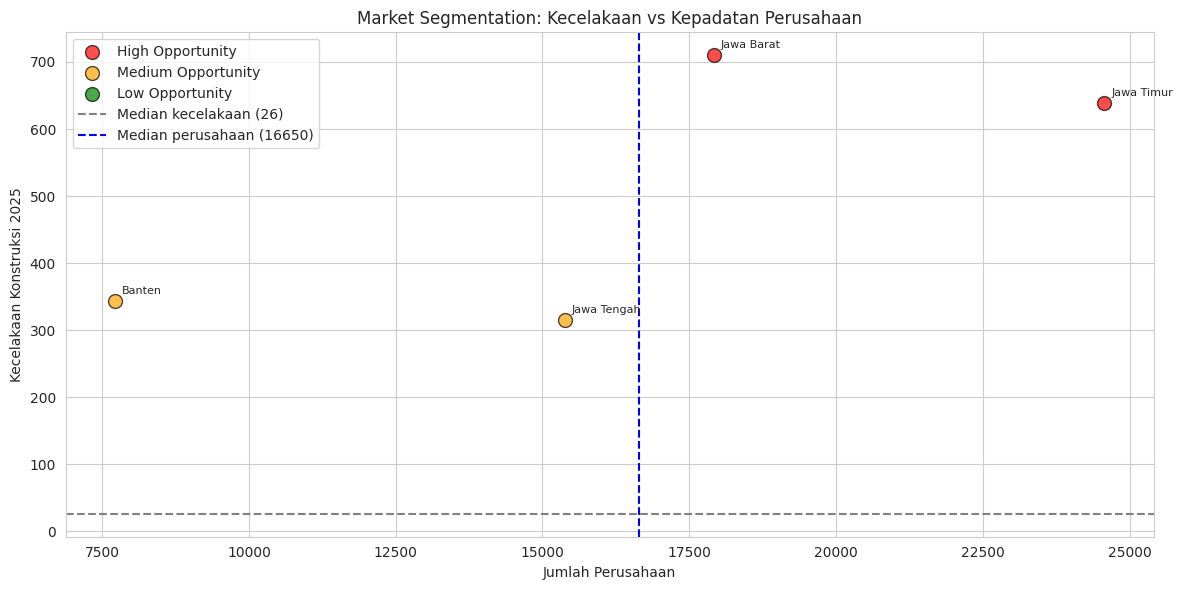

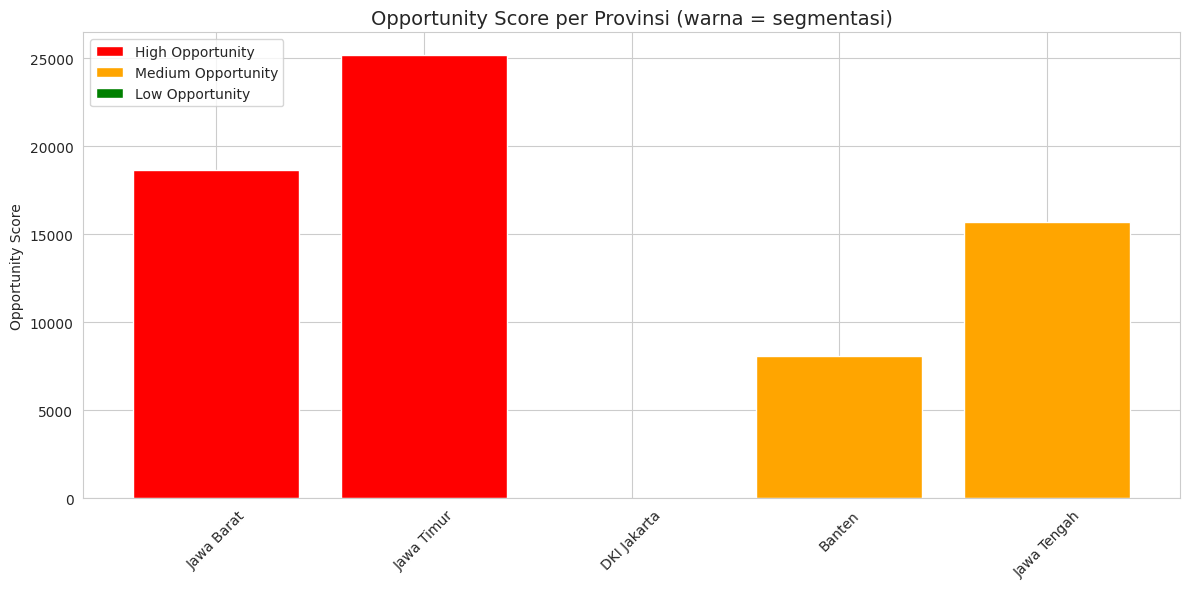

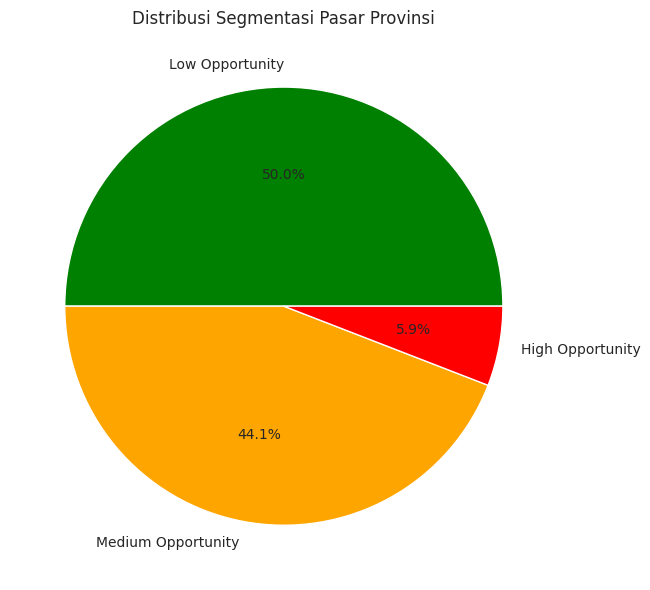


Hasil segmentasi disimpan ke 'Market_Segmentation.xlsx'

REKOMENDASI STRATEGI BERDASARKAN SEGMENTASI
High Opportunity (Kecelakaan Tinggi + Perusahaan Tinggi):
  - Prioritas utama untuk penjualan solusi K3 dan AI safety
  - Alokasikan tim sales dedicated
  - Tawarkan program pilot gratis untuk menarik minat

Medium Opportunity (Salah satu tinggi):
  - Fokus pada kelemahan: jika perusahaan banyak tapi kecelakaan rendah → edukasi pencegahan
  - Jika kecelakaan tinggi tapi perusahaan sedikit → bundling produk dengan harga kompetitif

Low Opportunity (Aktivitas rendah):
  - Canvassing massal dengan pendekatan digital marketing
  - Bangun awareness terlebih dahulu sebelum direct sales


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# MARKET SEGMENTATION ANALYSIS
# Segmentasi berdasarkan kecelakaan konstruksi dan jumlah perusahaan
# =============================================================================

# Asumsi: df_merged atau df_b2b sudah memiliki kolom:
#   - kecelakaan_konstruksi_2025
#   - total_perusahaan
# Jika belum, kita baca ulang

if 'df_merged' not in locals():
    # Gunakan df_kec dan df_perusahaan yang sudah ada
    if 'df_kec' in locals() and 'df_perusahaan' in locals():
        df_merged = df_kec.merge(df_perusahaan[['Provinsi', 'total_perusahaan']], on='Provinsi')
    else:
        # Baca ulang data
        file_kec = "Kecelakaan kerja 3 tahun.xlsx"
        df_kec_raw = pd.read_excel(file_kec, sheet_name="Sheet1", header=3)
        df_kec_raw = df_kec_raw.dropna(subset=["Provinsi"], how="all")
        df_kec = df_kec_raw[df_kec_raw["Provinsi"].notna() & (df_kec_raw["Provinsi"] != "Jumlah")].copy()
        kolom_2025 = df_kec.columns[9]
        df_kec = df_kec[["Provinsi", kolom_2025]].rename(columns={kolom_2025: "kecelakaan_konstruksi_2025"})
        df_kec["Provinsi"] = df_kec["Provinsi"].str.strip()

        file_perusahaan = "Perusahaan Konstruksi Jawa 2025.xlsx"
        sheets = ["Jatim", "Jateng", "Jawa Barat", "Banten"]
        provinsi_map = {"Jatim": "Jawa Timur", "Jateng": "Jawa Tengah",
                        "Jawa Barat": "Jawa Barat", "Banten": "Banten"}
        list_perusahaan = []
        for sheet in sheets:
            df_temp = pd.read_excel(file_perusahaan, sheet_name=sheet, header=1)
            last_row = df_temp.iloc[-1]
            jumlah_col = "Jumlah 2" if "Jumlah 2" in df_temp.columns else "Jumlah"
            total_perusahaan = last_row[jumlah_col]
            list_perusahaan.append({
                "Provinsi": provinsi_map[sheet],
                "total_perusahaan": total_perusahaan
            })
        df_perusahaan = pd.DataFrame(list_perusahaan)
        df_merged = df_kec.merge(df_perusahaan, on="Provinsi")

# =============================================================================
# Tentukan ambang batas "tinggi" (median atau mean)
# =============================================================================
median_kecelakaan = df_merged["kecelakaan_konstruksi_2025"].median()
median_perusahaan = df_merged["total_perusahaan"].median()

print("=" * 80)
print("MARKET SEGMENTATION ANALYSIS")
print("=" * 80)
print(f"Median kecelakaan konstruksi: {median_kecelakaan:.0f}")
print(f"Median jumlah perusahaan: {median_perusahaan:.0f}")
print("Kategori: High = nilai di atas median\n")

# Fungsi segmentasi
def segmentasi(row):
    kec_tinggi = row["kecelakaan_konstruksi_2025"] > median_kecelakaan
    per_tinggi = row["total_perusahaan"] > median_perusahaan
    if kec_tinggi and per_tinggi:
        return "High Opportunity"
    elif kec_tinggi or per_tinggi:
        return "Medium Opportunity"
    else:
        return "Low Opportunity"

df_merged["segment"] = df_merged.apply(segmentasi, axis=1)

# Urutkan berdasarkan opportunity descending
df_merged = df_merged.sort_values("kecelakaan_konstruksi_2025", ascending=False)

# =============================================================================
# CETAK HASIL SEGMENTASI
# =============================================================================
print("--- SEGMENTASI PER PROVINSI ---")
print(df_merged[["Provinsi", "kecelakaan_konstruksi_2025", "total_perusahaan", "segment"]]
      .to_string(index=False))

print("\n--- RINGKASAN SEGMENTASI ---")
segment_counts = df_merged["segment"].value_counts()
for seg in ["High Opportunity", "Medium Opportunity", "Low Opportunity"]:
    count = segment_counts.get(seg, 0)
    print(f"{seg}: {count} provinsi")

# =============================================================================
# SEGMENTASI TAMBAHAN: LEVEL KABUPATEN/KOTA (jika tersedia)
# =============================================================================
if 'df_hotspot' in locals() and not df_hotspot.empty:
    print("\n" + "=" * 80)
    print("SEGMENTASI LEVEL KABUPATEN/KOTA (Estimasi)")
    print("=" * 80)

    # Use a copy of df_hotspot as it already contains kecelakaan_konstruksi_2025 from previous steps
    df_hotspot_seg = df_hotspot.copy()

    # Hitung ambang batas untuk kab/kota
    median_perusahaan_kab = df_hotspot_seg["Jumlah_Perusahaan"].median()
    median_kecelakaan_kab = df_hotspot_seg["kecelakaan_konstruksi_2025"].median()

    print(f"Median perusahaan per kab/kota: {median_perusahaan_kab:.0f}")
    print(f"Median kecelakaan provinsi (sebagai proksi): {median_kecelakaan_kab:.0f}")

    def segmentasi_kab(row):
        kec_tinggi = row["kecelakaan_konstruksi_2025"] > median_kecelakaan_kab
        per_tinggi = row["Jumlah_Perusahaan"] > median_perusahaan_kab
        if kec_tinggi and per_tinggi:
            return "High Opportunity"
        elif kec_tinggi or per_tinggi:
            return "Medium Opportunity"
        else:
            return "Low Opportunity"

    df_hotspot_seg["segment_kab"] = df_hotspot_seg.apply(segmentasi_kab, axis=1)

    print("\nTop 10 Kab/Kota High Opportunity:")
    high_kab = df_hotspot_seg[df_hotspot_seg["segment_kab"] == "High Opportunity"].head(10)
    print(high_kab[["Kabupaten_Kota", "Provinsi", "Jumlah_Perusahaan", "segment_kab"]].to_string(index=False))

    print("\nRingkasan segmentasi kab/kota:")
    print(df_hotspot_seg["segment_kab"].value_counts())

# =============================================================================
# VISUALISASI SEGMENTASI
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Scatter plot: perusahaan vs kecelakaan, warna berdasarkan segment
fig1, ax1 = plt.subplots()
colors_seg = {"High Opportunity": "red", "Medium Opportunity": "orange", "Low Opportunity": "green"}
for seg, color in colors_seg.items():
    subset = df_merged[df_merged["segment"] == seg]
    ax1.scatter(subset["total_perusahaan"], subset["kecelakaan_konstruksi_2025"],
                label=seg, color=color, s=100, alpha=0.7, edgecolors='black')
# Tambahkan garis median
ax1.axhline(y=median_kecelakaan, color='gray', linestyle='--', label=f'Median kecelakaan ({median_kecelakaan:.0f})')
ax1.axvline(x=median_perusahaan, color='blue', linestyle='--', label=f'Median perusahaan ({median_perusahaan:.0f})')
for _, row in df_merged.iterrows():
    ax1.annotate(row["Provinsi"], (row["total_perusahaan"], row["kecelakaan_konstruksi_2025"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=8)
ax1.set_xlabel("Jumlah Perusahaan")
ax1.set_ylabel("Kecelakaan Konstruksi 2025")
ax1.set_title("Market Segmentation: Kecelakaan vs Kepadatan Perusahaan")
ax1.legend()
plt.tight_layout()
plt.savefig("market_segmentation_scatter.png", dpi=150)
plt.show()

# 2. Bar chart per provinsi dengan warna segment
fig2, ax2 = plt.subplots()
bar_colors = [colors_seg[seg] for seg in df_merged["segment"]]
bars = ax2.bar(df_merged["Provinsi"], df_merged["opportunity_score"] if "opportunity_score" in df_merged else df_merged["kecelakaan_konstruksi_2025"], color=bar_colors)
ax2.set_title("Opportunity Score per Provinsi (warna = segmentasi)", fontsize=14)
ax2.set_ylabel("Opportunity Score")
plt.xticks(rotation=45)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_seg['High Opportunity'], label='High Opportunity'),
                   Patch(facecolor=colors_seg['Medium Opportunity'], label='Medium Opportunity'),
                   Patch(facecolor=colors_seg['Low Opportunity'], label='Low Opportunity')]
ax2.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig("market_segmentation_bars.png", dpi=150)
plt.show()

# 3. Pie chart distribusi segmentasi
fig3, ax3 = plt.subplots()
segment_counts.plot(kind='pie', autopct='%1.1f%%', colors=[colors_seg[s] for s in segment_counts.index], ax=ax3)
ax3.set_title("Distribusi Segmentasi Pasar Provinsi")
ax3.set_ylabel("")
plt.tight_layout()
plt.savefig("market_segmentation_pie.png", dpi=150)
plt.show()

# =============================================================================
# EKSPORT KE EXCEL
# =============================================================================
with pd.ExcelWriter("Market_Segmentation.xlsx") as writer:
    df_merged.to_excel(writer, sheet_name="Segmentasi_Provinsi", index=False)
    if 'df_hotspot_seg' in locals():
        df_hotspot_seg.to_excel(writer, sheet_name="Segmentasi_Kab_Kota", index=False)
print("\nHasil segmentasi disimpan ke 'Market_Segmentation.xlsx'")

# =============================================================================
# REKOMENDASI STRATEGI PER SEGMEN
# =============================================================================
print("\n" + "=" * 80)
print("REKOMENDASI STRATEGI BERDASARKAN SEGMENTASI")
print("=" * 80)
print("High Opportunity (Kecelakaan Tinggi + Perusahaan Tinggi):")
print("  - Prioritas utama untuk penjualan solusi K3 dan AI safety")
print("  - Alokasikan tim sales dedicated")
print("  - Tawarkan program pilot gratis untuk menarik minat")
print("\nMedium Opportunity (Salah satu tinggi):")
print("  - Fokus pada kelemahan: jika perusahaan banyak tapi kecelakaan rendah \u2192 edukasi pencegahan")
print("  - Jika kecelakaan tinggi tapi perusahaan sedikit \u2192 bundling produk dengan harga kompetitif")
print("\nLow Opportunity (Aktivitas rendah):")
print("  - Canvassing massal dengan pendekatan digital marketing")
print("  - Bangun awareness terlebih dahulu sebelum direct sales")

**Segmentasi berdasarkan perusahaan**


--- Debugging Sheet: Jatim ---
Columns after type conversion: ['Provinsi', 'Kabupaten/Kota', 'Kecil', 'Menegah', 'Besar', 'Specialis', 'Tidak memiliki SBU Aktif', 'Jumlah 1', 'PT/Persero', 'CV', 'Koperasi', 'Kantor Perwakilan BUJKA', 'Lainnya', 'Jumlah 2']
Identified kab_col: Kabupaten/Kota
df_kab_raw head:
     Provinsi Kabupaten/Kota  Kecil  Menegah  Besar  Specialis  \
0  Jawa Timur       Pacitan     384      5.0    1.0        NaN   
1  Jawa Timur       Ponorogo    337      5.0    NaN        NaN   
2  Jawa Timur     Trenggalek    498      1.0    1.0        1.0   
3  Jawa Timur    Tulungagung    462      5.0    NaN        NaN   
4  Jawa Timur         Blitar    550      6.0    NaN        NaN   

   Tidak memiliki SBU Aktif  Jumlah 1  PT/Persero   CV  Koperasi  \
0                      23.0       412           6  406       NaN   
1                      10.0       353          14  339       NaN   
2                       3.0       503           7  496       NaN   
3                    

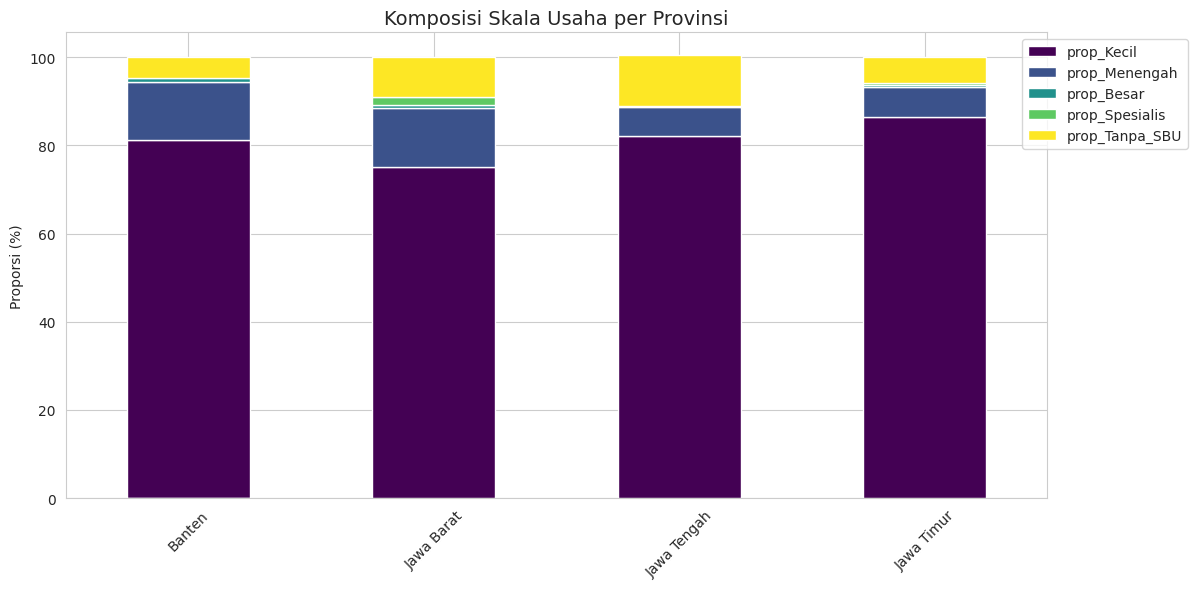

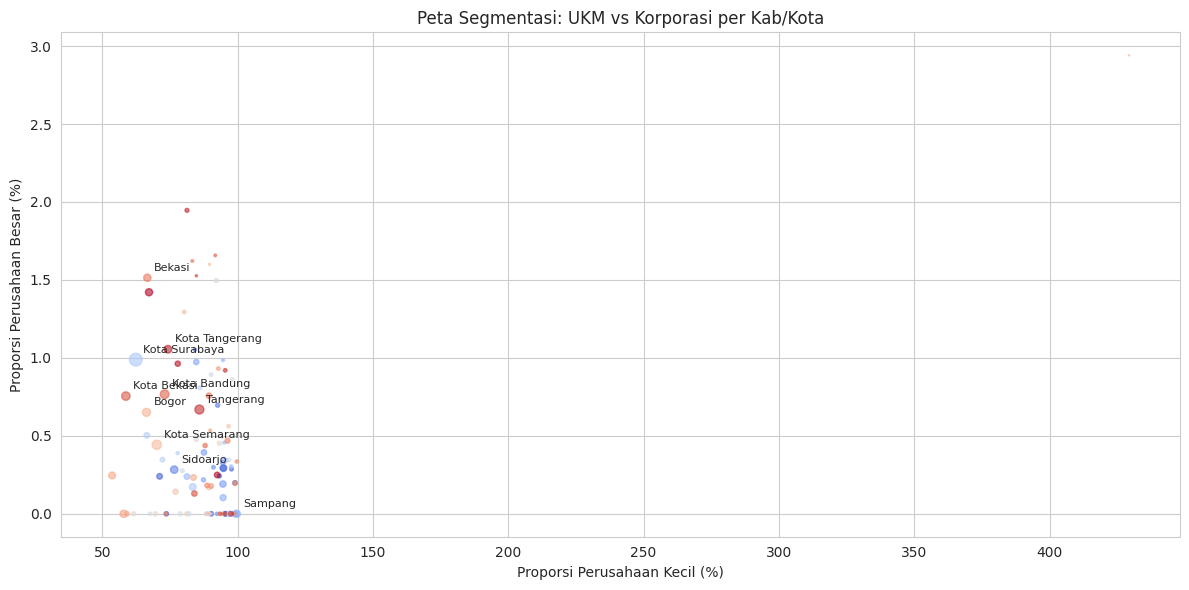


Hasil segmentasi yang telah diperbaiki disimpan ke 'Market_Segmentation_Fixed.xlsx'

REKOMENDASI STRATEGI BERDASARKAN SEGMENTASI
High Opportunity (Kecelakaan Tinggi + Perusahaan Tinggi):
  - Prioritas utama untuk penjualan solusi K3 dan AI safety
  - Alokasikan tim sales dedicated
  - Tawarkan program pilot gratis untuk menarik minat

Medium Opportunity (Salah satu tinggi):
  - Fokus pada kelemahan: jika perusahaan banyak tapi kecelakaan rendah → edukasi pencegahan
  - Jika kecelakaan tinggi tapi perusahaan sedikit → bundling produk dengan harga kompetitif

Low Opportunity (Aktivitas rendah):
  - Canvassing massal dengan pendekatan digital marketing
  - Bangun awareness terlebih dahulu sebelum direct sales


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# MARKET SEGMENTATION BERDASARKAN KARAKTERISTIK PERUSAHAAN (REVISI)
# =============================================================================

file_perusahaan = "Perusahaan Konstruksi Jawa 2025.xlsx"
sheets = ["Jatim", "Jateng", "Jawa Barat", "Banten"]
provinsi_map = {
    "Jatim": "Jawa Timur",
    "Jateng": "Jawa Tengah",
    "Jawa Barat": "Jawa Barat",
    "Banten": "Banten"
}

# Mapping nama kolom yang mungkin berbeda
skala_cols = {
    "Kecil": ["Kecil"],
    "Menengah": ["Menegah", "Menengah"],
    "Besar": ["Besar"],
    "Spesialis": ["Specialis", "Spesialis"],
    "Tanpa_SBU": ["Tidak memiliki SBU Aktif", "Tidak memiliki SBU Aktif "]
}
bentuk_cols = {
    "PT": ["PT/Persero"],
    "CV": ["CV"],
    "Koperasi": ["Koperasi"],
    "Lainnya": ["Lainnya", "Kantor Perwakilan BUJKA"]
}

def get_column(df_columns, possible_names):
    for name in possible_names:
        if name in df_columns:
            return name
    return None

list_kab = []

DEBUG_MODE = True # Set to True to enable debug prints

for sheet in sheets:
    # print(f"\n--- Inspecting raw data for Sheet: {sheet} ---")
    # df_raw_inspect = pd.read_excel(file_perusahaan, sheet_name=sheet, header=None)
    # print(df_raw_inspect.head(5)) # Print first 5 rows to see header candidates
    # print(f"--- End raw data inspection for Sheet: {sheet} ---")

    # Temporarily comment out the rest of the processing to focus on header identification
    df_temp = pd.read_excel(file_perusahaan, sheet_name=sheet, header=0)
    df_temp.columns = df_temp.columns.astype(str) # Crucial fix: convert column names to string

    if DEBUG_MODE:
        print(f"\n--- Debugging Sheet: {sheet} ---")
        print(f"Columns after type conversion: {df_temp.columns.tolist()}")

    # Ensure kab_col is correctly identified after converting columns to string
    kab_col = "Kabupaten/Kota"
    if kab_col not in df_temp.columns:
        # If 'Kabupaten/Kota' is not found as a string, it might be an unnamed column.
        # Fallback to the second column, which is often the case for city/regency name.
        # This assumes the first column is unnamed index or similar.
        kab_col = df_temp.columns[1]

    if DEBUG_MODE:
        print(f"Identified kab_col: {kab_col}")

    # Filter baris kab/kota (bukan total)
    df_kab_raw = df_temp[df_temp[kab_col].notna()].copy()
    df_kab_raw = df_kab_raw[~df_kab_raw[kab_col].astype(str).str.contains("Jumlah|Total", case=False, na=False)]

    if DEBUG_MODE:
        print(f"df_kab_raw head:\n{df_kab_raw.head()}")
        if df_kab_raw.empty:
            print(f"df_kab_raw is EMPTY for sheet {sheet} after filtering totals.")

    for idx, row in df_kab_raw.iterrows():
        data = {"Provinsi": provinsi_map[sheet], "Kabupaten_Kota": str(row[kab_col]).strip()}

        # Baca skala usaha
        for target, names in skala_cols.items():
            col_name = get_column(df_temp.columns, names)
            data[target] = row[col_name] if col_name and pd.notna(row.get(col_name)) else 0

        # Baca bentuk badan usaha
        for target, names in bentuk_cols.items():
            col_name = get_column(df_temp.columns, names)
            data[target] = row[col_name] if col_name and pd.notna(row.get(col_name)) else 0

        # Total perusahaan (prioritaskan kolom Jumlah)
        total_col_name = get_column(df_temp.columns, ["Jumlah 2", "Jumlah", "Jumlah 1"])
        if total_col_name:
            total = row[total_col_name]
        else:
            # Ensure all components used in sum are numeric or default to 0 for sum
            total = sum(data.get(k, 0) for k in ["Kecil", "Menengah", "Besar", "Spesialis", "Tanpa_SBU"])
        data["Total_Perusahaan"] = total if pd.notna(total) else 0

        list_kab.append(data)

        if DEBUG_MODE and idx == df_kab_raw.index[0]: # Print debug info only for the first row of each sheet
            print(f"First row data before appending to list_kab (Sheet {sheet}): {data}")

df_kab = pd.DataFrame(list_kab)

# Hapus baris dengan Total_Perusahaan = 0 atau NaN
df_kab = df_kab[df_kab["Total_Perusahaan"] > 0].copy()

if DEBUG_MODE:
    if df_kab.empty:
        print("df_kab is EMPTY after filtering Total_Perusahaan > 0.")
    else:
        print(f"df_kab head after filtering:\n{df_kab.head()}")

# Hitung proporsi (dalam %)
# Ensure these columns exist before calculating proportions
for col in ["Kecil", "Menengah", "Besar", "Spesialis", "Tanpa_SBU", "PT", "CV", "Koperasi", "Lainnya"]:
    if col in df_kab.columns:
        # Only calculate if Total_Perusahaan is not zero to avoid division by zero
        df_kab[f"prop_{col}"] = (df_kab[col] / df_kab["Total_Perusahaan"]) * 100
        df_kab[f"prop_{col}"] = df_kab[f"prop_{col}"].fillna(0) # Replace NaN from division by zero with 0
    else:
        df_kab[f"prop_{col}"] = 0


# =============================================================================
# SEGMENTASI (berdasarkan karakteristik dominan)
# =============================================================================
def tentukan_segmen(row):
    # Ensure prop_Besar, prop_PT, etc. are handled if they are NaN (e.g., if Total_Perusahaan was 0 for some reason)
    prop_besar = row.get("prop_Besar", 0)
    prop_pt = row.get("prop_PT", 0)
    prop_spesialis = row.get("prop_Spesialis", 0)
    prop_tanpa_sbu = row.get("prop_Tanpa_SBU", 0)
    prop_kecil = row.get("prop_Kecil", 0)
    prop_cv = row.get("prop_CV", 0)
    prop_menengah = row.get("prop_Menengah", 0)


    if prop_besar > 10 or prop_pt > 20:
        return "Pasar Korporasi (Besar & PT)"
    elif prop_spesialis > 15 or prop_tanpa_sbu > 30:
        return "Pasar Spesialis & Risiko Tinggi"
    elif prop_kecil > 70 or prop_cv > 80:
        return "Pasar UKM Dominan"
    elif prop_menengah > 30:
        return "Pasar Menengah"
    else:
        return "Pasar Campuran"

df_kab["Segmentasi"] = df_kab.apply(tentukan_segmen, axis=1)

# =============================================================================
# AGREGASI PER PROVINSI
# =============================================================================
# Ensure all columns used in agg exist in df_kab before groupby
cols_to_sum = ["Total_Perusahaan", "Kecil", "Menengah", "Besar", "Spesialis", "Tanpa_SBU", "PT", "CV", "Koperasi", "Lainnya"]
existing_cols_to_sum = [col for col in cols_to_sum if col in df_kab.columns]

# Only attempt aggregation if df_kab is not empty
if not df_kab.empty:
    df_prov = df_kab.groupby("Provinsi")[existing_cols_to_sum].sum().reset_index()

    for col in ["Kecil", "Menengah", "Besar", "Spesialis", "Tanpa_SBU", "PT", "CV"]:
        if col in df_prov.columns:
            df_prov[f"prop_{col}"] = (df_prov[col] / df_prov["Total_Perusahaan"]) * 100
            df_prov[f"prop_{col}"] = df_prov[f"prop_{col}"].fillna(0) # Replace NaN from division by zero with 0
        else:
            df_prov[f"prop_{col}"] = 0

    def segmen_prov(row):
        prop_besar = row.get("prop_Besar", 0)
        prop_pt = row.get("prop_PT", 0)
        prop_spesialis = row.get("prop_Spesialis", 0)
        prop_tanpa_sbu = row.get("prop_Tanpa_SBU", 0)
        prop_kecil = row.get("prop_Kecil", 0)
        prop_cv = row.get("prop_CV", 0)
        prop_menengah = row.get("prop_Menengah", 0)

        if prop_besar > 10 or prop_pt > 20:
            return "Pasar Korporasi"
        elif prop_spesialis > 10 or prop_tanpa_sbu > 25:
            return "Pasar Spesialis & Risiko"
        elif prop_kecil > 70 or prop_cv > 80:
            return "Pasar UKM"
        elif prop_menengah > 25:
            return "Pasar Menengah"
        else:
            return "Pasar Campuran"

    df_prov["Segmentasi_Provinsi"] = df_prov.apply(segmen_prov, axis=1)
else:
    df_prov = pd.DataFrame(columns=["Provinsi"] + existing_cols_to_sum + [f"prop_{c}" for c in ["Kecil", "Menengah", "Besar", "Spesialis", "Tanpa_SBU", "PT", "CV"]] + ["Segmentasi_Provinsi"])

# =============================================================================
# OUTPUT & VISUALISASI
# =============================================================================
print("="*80)
print("SEGMENTASI BERDASARKAN KARAKTERISTIK PERUSAHAAN (REVISI)")
print("="*80)
print("\n--- PROPORSI SKALA USAHA PER PROVINSI (dalam %) ---")
# Only print columns that exist
cols_to_print = ["Provinsi", "prop_Kecil", "prop_Menengah", "prop_Besar", "prop_Spesialis", "prop_Tanpa_SBU"]
existing_cols_to_print = [col for col in cols_to_print if col in df_prov.columns]
if not df_prov.empty and not df_prov[existing_cols_to_print].empty: # Add check for empty dataframe and columns
    print(df_prov[existing_cols_to_print].round(2))
else:
    print("Empty DataFrame or no relevant columns to display for df_prov.")

print("\n--- SEGMENTASI PROVINSI ---")
if not df_prov.empty:
    print(df_prov[["Provinsi", "Segmentasi_Provinsi"]])
else:
    print("Empty DataFrame for df_prov.")

print("\n--- TOP 5 KAB/KOTA TIAP SEGMEN ---")
if not df_kab.empty: # Add check for empty dataframe
    for seg in df_kab["Segmentasi"].unique():
        print(f"\n{seg}:")
        top = df_kab[df_kab["Segmentasi"] == seg].nlargest(3, "Total_Perusahaan")
        cols_for_top = ["Kabupaten_Kota", "Provinsi", "Total_Perusahaan", "prop_Kecil", "prop_Besar", "prop_CV"]
        existing_cols_for_top = [col for col in cols_for_top if col in top.columns]
        print(top[existing_cols_for_top].round(1).to_string(index=False))
else:
    print("df_kab is empty, cannot display top KAB/KOTA.")


# =============================================================================
# PLOT ULANG (dengan data yang benar)
# =============================================================================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Stacked bar proporsi skala per provinsi
if not df_prov.empty: # Add check for empty dataframe
    fig1, ax1 = plt.subplots()
    cols_for_skala = ["prop_Kecil", "prop_Menengah", "prop_Besar", "prop_Spesialis", "prop_Tanpa_SBU"]
    existing_cols_for_skala = [col for col in cols_for_skala if col in df_prov.columns]
    if not existing_cols_for_skala:
        print("No valid columns for skala plot in df_prov.")
    else:
        df_skala = df_prov.set_index("Provinsi")[existing_cols_for_skala]
        df_skala.plot(kind="bar", stacked=True, ax=ax1, colormap="viridis")
        ax1.set_title("Komposisi Skala Usaha per Provinsi", fontsize=14)
        ax1.set_ylabel("Proporsi (%)")
        ax1.set_xlabel("")
        plt.xticks(rotation=45)
        plt.legend(loc="upper right", bbox_to_anchor=(1.15,1))
        plt.tight_layout()
        plt.savefig("segmentasi_skala_provinsi_fixed.png")
        plt.show()
else:
    print("df_prov is empty, cannot generate stacked bar plot for provinsi.")


# 2. Bubble chart proporsi Kecil vs Besar (seharusnya tidak lagi 0)
if not df_kab.empty and "prop_Kecil" in df_kab.columns and "prop_Besar" in df_kab.columns: # Add check for empty dataframe and columns
    fig2, ax2 = plt.subplots()
    scatter = ax2.scatter(df_kab["prop_Kecil"], df_kab["prop_Besar"],
                          s=df_kab["Total_Perusahaan"]/50, alpha=0.6,
                          c=range(len(df_kab)), cmap="coolwarm")
    ax2.set_xlabel("Proporsi Perusahaan Kecil (%)")
    ax2.set_ylabel("Proporsi Perusahaan Besar (%)")
    ax2.set_title("Peta Segmentasi: UKM vs Korporasi per Kab/Kota")
    # Only label top 10 if there are enough rows
    if len(df_kab) > 10:
        for _, row in df_kab.nlargest(10, "Total_Perusahaan").iterrows():
            ax2.annotate(row["Kabupaten_Kota"], (row["prop_Kecil"], row["prop_Besar"]),
                         xytext=(5,5), textcoords="offset points", fontsize=8)
    else:
        for _, row in df_kab.iterrows(): # Label all if less than 10
            ax2.annotate(row["Kabupaten_Kota"], (row["prop_Kecil"], row["prop_Besar"]),
                         xytext=(5,5), textcoords="offset points", fontsize=8)
    plt.tight_layout()
    plt.savefig("segmentasi_bubble_fixed.png")
    plt.show()
else:
    print("df_kab is empty or missing necessary proportion columns, cannot generate bubble chart for kab/kota.")


# =============================================================================
# EKSPORT HASIL
# =============================================================================
with pd.ExcelWriter("Market_Segmentation_Fixed.xlsx") as writer:
    if not df_kab.empty:
        df_kab.to_excel(writer, sheet_name="Segmentasi_Kab_Kota", index=False)
    else:
        print("df_kab is empty, skipping export to 'Segmentasi_Kab_Kota' sheet.")
    if not df_prov.empty:
        df_prov.to_excel(writer, sheet_name="Segmentasi_Provinsi", index=False)
    else:
        print("df_prov is empty, skipping export to 'Segmentasi_Provinsi' sheet.")
print("\nHasil segmentasi yang telah diperbaiki disimpan ke 'Market_Segmentation_Fixed.xlsx'")

# =============================================================================
# REKOMENDASI STRATEGI PER SEGMEN
# =============================================================================
print("\n" + "=" * 80)
print("REKOMENDASI STRATEGI BERDASARKAN SEGMENTASI")
print("=" * 80)
print("High Opportunity (Kecelakaan Tinggi + Perusahaan Tinggi):")
print("  - Prioritas utama untuk penjualan solusi K3 dan AI safety")
print("  - Alokasikan tim sales dedicated")
print("  - Tawarkan program pilot gratis untuk menarik minat")
print("\nMedium Opportunity (Salah satu tinggi):")
print("  - Fokus pada kelemahan: jika perusahaan banyak tapi kecelakaan rendah \u2192 edukasi pencegahan")
print("  - Jika kecelakaan tinggi tapi perusahaan sedikit \u2192 bundling produk dengan harga kompetitif")
print("\nLow Opportunity (Aktivitas rendah):")
print("  - Canvassing massal dengan pendekatan digital marketing")
print("  - Bangun awareness terlebih dahulu sebelum direct sales")

SEGMENTASI PASAR BERDASARKAN KARAKTERISTIK PERUSAHAAN

--- SEGMENTASI PER KABUPATEN/KOTA (Top 10 setiap segmen) ---

Pasar Campuran:
Kabupaten_Kota   Provinsi  Total_Perusahaan  prop_Kecil  prop_Besar  prop_CV
      Ponorogo Jawa Timur                 0         NaN         NaN      NaN
    Trenggalek Jawa Timur                 0         NaN         NaN      NaN
   Tulungagung Jawa Timur                 0         NaN         NaN      NaN
        Blitar Jawa Timur                 0         NaN         NaN      NaN
        Kediri Jawa Timur                 0         NaN         NaN      NaN

--- SEGMENTASI PER PROVINSI ---
   Provinsi  Total_Perusahaan  prop_Kecil  prop_Besar  prop_CV Segmentasi_Provinsi
     Banten                 0         NaN         NaN      NaN      Pasar Campuran
 Jawa Barat                 0         NaN         NaN      NaN      Pasar Campuran
Jawa Tengah                 0         NaN         NaN      NaN      Pasar Campuran
 Jawa Timur                 0         Na

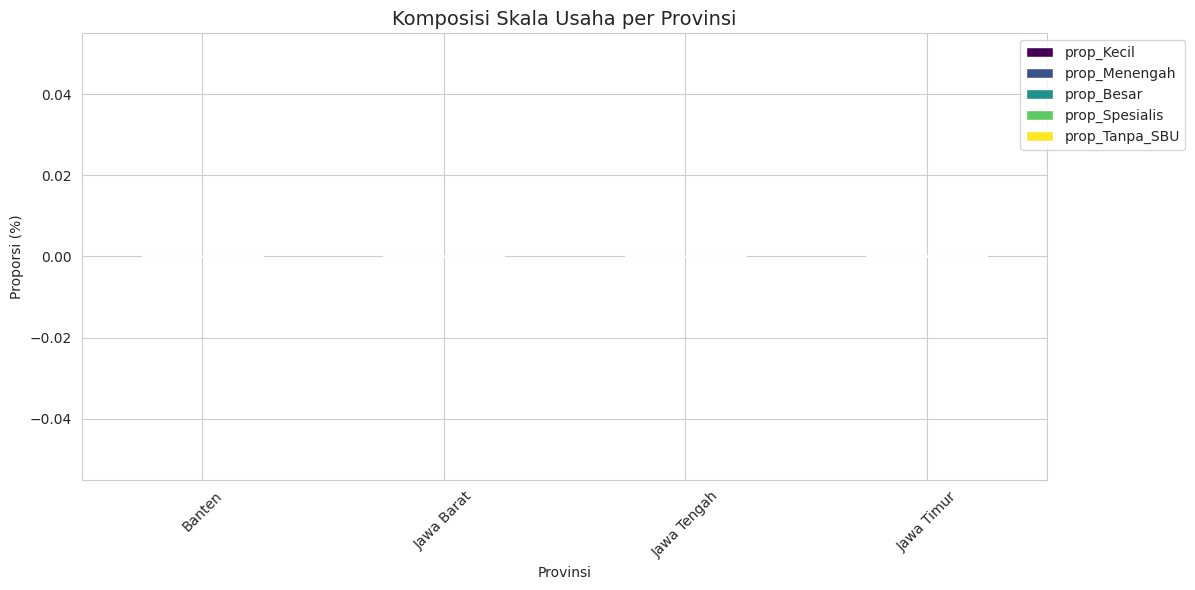

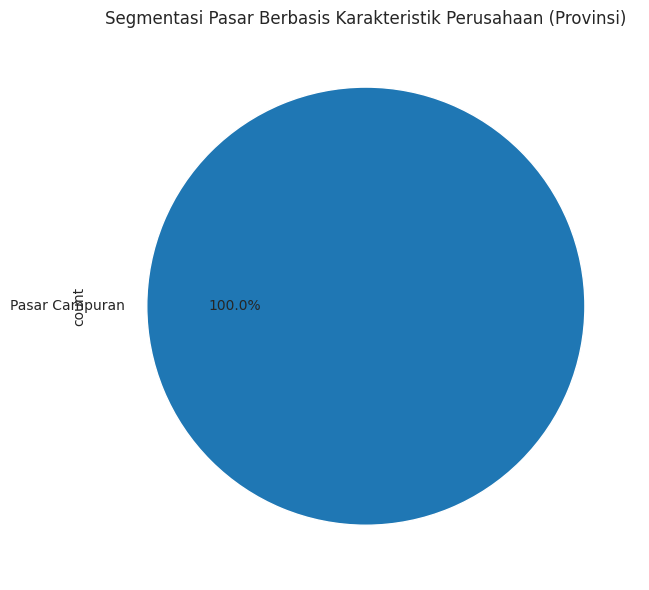

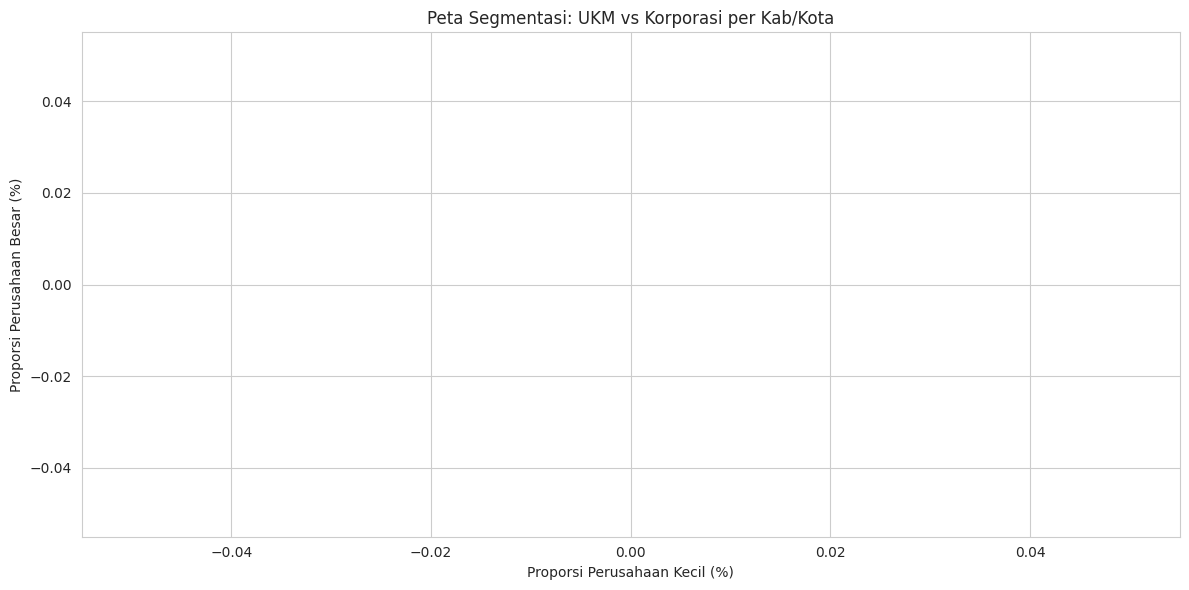


Hasil segmentasi disimpan ke 'Market_Segmentation_Based_on_Company_Characteristics.xlsx'


In [ ]:
# =============================================================================
# MARKET SEGMENTATION BERDASARKAN KARAKTERISTIK PERUSAHAAN
# Mengelompokkan kabupaten/kota berdasarkan proporsi skala usaha & bentuk badan usaha
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Asumsi: df_perusahaan_detail sudah berisi data per kab/kota dengan kolom:
# - Kecil, Menengah, Besar, Spesialis, Tidak_memiliki_SBU_Aktif
# - PT, CV, Koperasi, Lainnya
# Jika belum, baca ulang dari file

file_perusahaan = "Perusahaan Konstruksi Jawa 2025.xlsx"
sheets = ["Jatim", "Jateng", "Jawa Barat", "Banten"]
provinsi_map = {"Jatim": "Jawa Timur", "Jateng": "Jawa Tengah",
                "Jawa Barat": "Jawa Barat", "Banten": "Banten"}

list_kab = []

for sheet in sheets:
    df_temp = pd.read_excel(file_perusahaan, sheet_name=sheet, header=1)
    kab_col = "Kabupaten/Kota" if "Kabupaten/Kota" in df_temp.columns else df_temp.columns[1]
    # Ambil semua baris kecuali total
    df_kab = df_temp[df_temp[kab_col].notna()].copy()
    df_kab = df_kab[~df_kab[kab_col].isin(["Jumlah", "Total", "Jumlah ", "Total "])]

    for _, row in df_kab.iterrows():
        # Ekstrak kolom skala usaha
        kecil = row.get("Kecil", 0)
        menengah = row.get("Menegah", row.get("Menengah", 0))
        besar = row.get("Besar", 0)
        spesialis = row.get("Specialis", row.get("Spesialis", 0))
        tanpa_sbu = row.get("Tidak memiliki SBU Aktif", 0)
        total_skala = kecil + menengah + besar + spesialis + tanpa_sbu

        # Ekstrak bentuk badan usaha
        pt = row.get("PT/Persero", 0)
        cv = row.get("CV", 0)
        koperasi = row.get("Koperasi", 0)
        # Lainnya bisa gabungan dari "Lainnya" dan "Kantor Perwakilan BUJKA"
        lainnya = row.get("Lainnya", 0)
        if "Kantor Perwakilan BUJKA" in row:
            lainnya += row.get("Kantor Perwakilan BUJKA", 0)
        total_badan = pt + cv + koperasi + lainnya

        list_kab.append({
            "Provinsi": provinsi_map[sheet],
            "Kabupaten_Kota": row[kab_col],
            "Total_Perusahaan": row.get("Jumlah 2", row.get("Jumlah", total_skala)),
            "Kecil": kecil,
            "Menengah": menengah,
            "Besar": besar,
            "Spesialis": spesialis,
            "Tanpa_SBU": tanpa_sbu,
            "PT": pt,
            "CV": cv,
            "Koperasi": koperasi,
            "Lainnya": lainnya
        })

df_kab = pd.DataFrame(list_kab)

# Hitung proporsi (%) untuk skala usaha
for col in ["Kecil", "Menengah", "Besar", "Spesialis", "Tanpa_SBU"]:
    df_kab[f"prop_{col}"] = df_kab[col] / df_kab["Total_Perusahaan"] * 100

# Hitung proporsi bentuk badan usaha
for col in ["PT", "CV", "Koperasi", "Lainnya"]:
    df_kab[f"prop_{col}"] = df_kab[col] / df_kab["Total_Perusahaan"] * 100

# =============================================================================
# SEGMENTASI BERDASARKAN KARAKTERISTIK DOMINAN
# =============================================================================

def tentukan_segmen(row):
    # Skala usaha dominan
    if row["prop_Besar"] > 10 or row["prop_PT"] > 20:
        return "Pasar Korporasi (Besar & PT)"
    elif row["prop_Spesialis"] > 15 or (row["prop_Tanpa_SBU"] > 30):
        return "Pasar Spesialis & Risiko Tinggi"
    elif row["prop_Kecil"] > 70 or row["prop_CV"] > 80:
        return "Pasar UKM Dominan"
    elif row["prop_Menengah"] > 30:
        return "Pasar Menengah"
    else:
        return "Pasar Campuran"

df_kab["Segmentasi_Pasar"] = df_kab.apply(tentukan_segmen, axis=1)

# =============================================================================
# AGREGAT PER PROVINSI (berdasarkan karakteristik perusahaan)
# =============================================================================
df_prov_seg = df_kab.groupby("Provinsi").agg({
    "Total_Perusahaan": "sum",
    "Kecil": "sum",
    "Menengah": "sum",
    "Besar": "sum",
    "Spesialis": "sum",
    "Tanpa_SBU": "sum",
    "PT": "sum",
    "CV": "sum"
}).reset_index()

# Hitung proporsi provinsi
for col in ["Kecil", "Menengah", "Besar", "Spesialis", "Tanpa_SBU", "PT", "CV"]:
    df_prov_seg[f"prop_{col}"] = df_prov_seg[col] / df_prov_seg["Total_Perusahaan"] * 100

def segmen_provinsi(row):
    if row["prop_Besar"] > 10 or row["prop_PT"] > 20:
        return "Pasar Korporasi"
    elif row["prop_Spesialis"] > 10 or row["prop_Tanpa_SBU"] > 25:
        return "Pasar Spesialis & Risiko"
    elif row["prop_Kecil"] > 70 or row["prop_CV"] > 80:
        return "Pasar UKM"
    elif row["prop_Menengah"] > 25:
        return "Pasar Menengah"
    else:
        return "Pasar Campuran"

df_prov_seg["Segmentasi_Provinsi"] = df_prov_seg.apply(segmen_provinsi, axis=1)

# =============================================================================
# CETAK HASIL
# =============================================================================
print("=" * 80)
print("SEGMENTASI PASAR BERDASARKAN KARAKTERISTIK PERUSAHAAN")
print("=" * 80)

print("\n--- SEGMENTASI PER KABUPATEN/KOTA (Top 10 setiap segmen) ---")
for seg in df_kab["Segmentasi_Pasar"].unique():
    print(f"\n{seg}:")
    top = df_kab[df_kab["Segmentasi_Pasar"] == seg].nlargest(5, "Total_Perusahaan")
    print(top[["Kabupaten_Kota", "Provinsi", "Total_Perusahaan", "prop_Kecil", "prop_Besar", "prop_CV"]].to_string(index=False))

print("\n--- SEGMENTASI PER PROVINSI ---")
print(df_prov_seg[["Provinsi", "Total_Perusahaan", "prop_Kecil", "prop_Besar", "prop_CV", "Segmentasi_Provinsi"]].to_string(index=False))

print("\n--- RINGKASAN SEGMENTASI PROVINSI ---")
print(df_prov_seg["Segmentasi_Provinsi"].value_counts())

# =============================================================================
# VISUALISASI
# =============================================================================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Stacked bar proporsi skala usaha per provinsi
fig1, ax1 = plt.subplots()
df_skala_prov = df_prov_seg.set_index("Provinsi")[["prop_Kecil", "prop_Menengah", "prop_Besar", "prop_Spesialis", "prop_Tanpa_SBU"]]
df_skala_prov.plot(kind="bar", stacked=True, ax=ax1, colormap="viridis")
ax1.set_title("Komposisi Skala Usaha per Provinsi", fontsize=14)
ax1.set_ylabel("Proporsi (%)")
plt.xticks(rotation=45)
plt.legend(loc="upper right", bbox_to_anchor=(1.15,1))
plt.tight_layout()
plt.savefig("segmentasi_skala_provinsi.png")
plt.show()

# 2. Pie chart segmentasi provinsi
fig2, ax2 = plt.subplots()
df_prov_seg["Segmentasi_Provinsi"].value_counts().plot(kind="pie", autopct='%1.1f%%', ax=ax2)
ax2.set_title("Segmentasi Pasar Berbasis Karakteristik Perusahaan (Provinsi)")
plt.tight_layout()
plt.savefig("segmentasi_provinsi_pie.png")
plt.show()

# 3. Bubble chart: proporsi UKM vs proporsi korporasi per kab/kota
fig3, ax3 = plt.subplots()
scatter = ax3.scatter(df_kab["prop_Kecil"], df_kab["prop_Besar"],
                      s=df_kab["Total_Perusahaan"]/50, alpha=0.5,
                      c=range(len(df_kab)), cmap="coolwarm")
ax3.set_xlabel("Proporsi Perusahaan Kecil (%)")
ax3.set_ylabel("Proporsi Perusahaan Besar (%)")
ax3.set_title("Peta Segmentasi: UKM vs Korporasi per Kab/Kota")
# Label hanya untuk top 10
top10 = df_kab.nlargest(10, "Total_Perusahaan")
for _, row in top10.iterrows():
    ax3.annotate(row["Kabupaten_Kota"], (row["prop_Kecil"], row["prop_Besar"]),
                 xytext=(5,5), textcoords="offset points", fontsize=8)
plt.tight_layout()
plt.savefig("segmentasi_ukm_vs_korporasi.png")
plt.show()

# =============================================================================
# EKSPORT KE EXCEL
# =============================================================================
with pd.ExcelWriter("Market_Segmentation_Based_on_Company_Characteristics.xlsx") as writer:
    df_kab.to_excel(writer, sheet_name="Segmentasi_Kab_Kota", index=False)
    df_prov_seg.to_excel(writer, sheet_name="Segmentasi_Provinsi", index=False)
print("\nHasil segmentasi disimpan ke 'Market_Segmentation_Based_on_Company_Characteristics.xlsx'")